# Matching and comparison of the database with external sources

In [2]:
%load_ext autoreload
%autoreload 2

In [1]:
import pandas as pd
import ast
import geopandas as gpd
from copy import deepcopy as dc
from matplotlib.ticker import LogLocator, FuncFormatter
import matplotlib.pyplot as plt

import os
import sys
current_dir = os.getcwd()
project_root = os.path.dirname(current_dir)
sys.path.append(project_root)

from src.data import *
from src.post_process_functions import *
from src.hazard_def import *
from src.external_comparaison import *
from src.data_format import format_output, LIST_COLS

path_save_fig = DATA_FIGURE / "validation_external_sources"
#sys.path.append('/home/lhasbini/como_school/como_project4/src/')

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lhasbini\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [3]:
# 200 reports
# res_name_llm = "post_processed_monty_200rep_meta-llama_llama-4-scout-17b-16e-instruct_v190925"
# res_name_llm = "filtered_post_processed_geocoded_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_geo_v171225"
# res_name_llm = "merged_subtypespost_processed_all_appeals_longest_1-717_meta-llama_llama-4-scout-17b-16e-instruct_v121225_v120226_geo"
# res_name_llm = "post_processed_0-350_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v200426_v210426_geo"
# res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v230426_v230426_geo"
# res_name_llm = "post_processed_0-717_latest_reports_1quali_chunksize1000_Noneit_meta-llama_llama-4-scout-17b-16e-instruct_v240426_v240426_geo"
res_name_llm = "filter_merged_post_processed_0-778_llm_response_preproc_text_sel_gaps_combined_v300626_v060726_2016-2025_meta-llama_llama-4-scout-17b-16e-instruct_v060726_v080726_geo"

cols = [
    "appealCode",
    "reportDate",
    "impactSubtype",
    "impactValue",
    "impactValueMin",
    "impactValueMax",
    "impactValuePrecision",
    "impactUnit",
    "valueAnnotation",
    "location",
    "locationAnnotation",
    "locationPolygon",
    "locationLowestAdmin",
    "country_robust_iso3",
    "hazards",
    'startYear',
    'startMonth',
    'startDay',
    'endYear',
    'endMonth',
    'endDay'
]
# df_llm_all_geo = pd.read_parquet(DATA_OUT_PROC/(res_name_llm+'.parquet'), columns=cols)
df_llm_all = pd.read_parquet(os.path.join(DATA_OUT_PROC, res_name_llm+'.parquet'))
df_llm_all = df_llm_all.drop(columns=["geometry"])
# df_llm_all = format_output(df_llm_all, list_cols=LIST_COLS+["country_robust_iso3"])
# df_llm_all_geo = gpd.read_file(os.path.join(DATA_OUT_PROC, res_name_llm+'_geo_v191225.gpkg'))

# col_to_list = ["location", "country", "country_kw", "country_iso3", "hazards"]
# df_llm_all[col_to_list] = df_llm_all[col_to_list].map(lambda x: listify_strings(x))

# col_to_list = ["location", "locationPolygon", "iso3_code", "hazards"]
# df_llm_all_geo[col_to_list] = df_llm_all_geo[col_to_list].map(lambda x: listify_strings(x))

In [12]:
df_llm_all.appealCode.nunique()

776

In [4]:
df_llm_all_geo_grp = clean_group(df_llm_all, ADM_min=0)

In [5]:
# Import data from other sources
df_ifrc_go = open_clean_ifrc_go()
df_ifrc_go_2016 = df_ifrc_go[df_ifrc_go.appeals_start_date > '2016-01-01']
# df_ifrc_monty = open_clean_ifrc_monty(df_ifrc_go)
df_em_dat = open_emdat()

df_external_source = {}
df_external_source["IFRCGO"] = df_ifrc_go
# df_external_source["ifrc_monty"] = df_ifrc_monty
df_external_source["EMDAT"] = df_em_dat

In [8]:
df_llm_all_geo_grp_linked = {}

# # MATCHING WITH IFRC MONTY
# df_ifrc_monty_subset = df_ifrc_monty[["appealCode", "impact_type", "impact_value", "impact_category"]]
# df_llm_all_geo_grp_linked["ifrc_monty"] = df_llm_all_geo_grp.merge(df_ifrc_monty_subset, left_on=["appealCode", "impactSubtype"], right_on=["appealCode", "impact_type"])

# IFRCGO
df_ifrc_go_clean = clean_structure_ifrc_go(df_ifrc_go)
df_llm_all_geo_grp_linked["IFRCGO"] = df_llm_all_geo_grp.merge(
    df_ifrc_go_clean,
    left_on=["appealCode", "impactSubtype"],
    right_on=["IFRCGO_appealCode", "IFRCGO_impactSubtype"],
    how="left",
)

# Build long-format EMDAT impacts
df_em_dat_clean = clean_structure_emdat(df_em_dat)
df_em_dat_clean.head()

# MATCHING WITH EMDAT
months = 3
date_diff_th = datetime.timedelta(days=months*30)
df_llm_all_geo_linked, df_llm_em_dat = matching_emdat(
    df_llm_all_geo_grp,
    df_em_dat_clean,
    date_diff_th,
    "date_diff_start",
    country_field='country_iso3',
)
df_llm_all_geo_grp_linked["EMDAT"] = df_llm_all_geo_linked

# Combined linked dataframe with both EMDAT and IFRCGO matched columns
ifrc_cols = [c for c in df_llm_all_geo_grp_linked["IFRCGO"].columns if c.startswith("IFRCGO_")]
df_llm_all_linked = df_llm_all_geo_grp_linked["EMDAT"].merge(
    df_llm_all_geo_grp_linked["IFRCGO"][["appealCode", "impactSubtype"] + ifrc_cols].drop_duplicates(),
    on=["appealCode", "impactSubtype"],
    how="left",
)
df_llm_all_geo_grp_linked["ALL"] = df_llm_all_linked

c:\Users\lhasbini\ownCloud\Documents\Thèse\programs\como_project4\como_project4\src\external_comparaison.py:481: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: choose_unique_disno(x, column_minimize))


In [9]:
print("Number of IFRCGO events extracted : ", df_ifrc_go.appealCode.nunique())
print("Number of IFRCGO events extracted after 2016 : ", df_ifrc_go_2016.appealCode.nunique())
print("Number of unique appeal codes in IFRCGO linked dataframe:", df_llm_all_geo_grp_linked["IFRCGO"].IFRCGO_appealCode.nunique())

Number of IFRCGO events extracted :  2728
Number of IFRCGO events extracted after 2016 :  688
Number of unique appeal codes in IFRCGO linked dataframe: 346


In [10]:
# Look for the appeals which are in ROUGE (df_llm_all_geo_grp) but not in df_ifrc_go_2016
appeal_in_rouge = df_llm_all.appealCode.unique()
appeal_in_ifrc_go_2016 = df_ifrc_go_2016.appealCode.unique()
appeal_diff_rouge = set(appeal_in_rouge) - set(appeal_in_ifrc_go_2016)
print("Number of appeals in ROUGE but not in IFRCGO after 2016:", len(appeal_diff_rouge))
appeal_diff_ifrcgo = set(appeal_in_ifrc_go_2016) - set(appeal_in_rouge)
print("Number of appeals in IFRCGO after 2016 but not in ROUGE:", len(appeal_diff_ifrcgo))
print("Number of appeals both in ROUGE and IFRCGO after 2016:", len(set(appeal_in_rouge).intersection(set(appeal_in_ifrc_go_2016))))

Number of appeals in ROUGE but not in IFRCGO after 2016: 176
Number of appeals in IFRCGO after 2016 but not in ROUGE: 88
Number of appeals both in ROUGE and IFRCGO after 2016: 600


# Global plots

Need to plot informations about the raw dataset, such as : 
- Map with the number of event per country --> Need to filter over the same period 
- Total number of affected people (per year per country ?)
- % of reports for which we have information about each Impact Category (before matching with the ones extracted with LLM)

In [13]:
impact_subtypes = list(mapping_impact_type.keys())

### Plot of % of reports with impact information 

In [14]:
# Build counts/% for ROUGE + linked IFRCGO + linked EMDAT
impact_subtypes_input = list(mapping_impact_type.keys())

linked_sources_cfg = {
    "IFRCGO": {
        "df": df_llm_all_geo_grp_linked["IFRCGO"],
        "value_col": "IFRCGO_impactValue",
        "source_subtype_col": "IFRCGO_impactSubtype",
    },
    "EMDAT": {
        "df": df_llm_all_geo_grp_linked["EMDAT"],
        "value_col": "EMDAT_impactValue",
        "source_subtype_col": "EMDAT_ImpactSubtype",
    },
}

impact_count_summary, nb_report_with_impact, perc_report_with_impact = count_impacts_by_subtype(
    df_rouge=df_llm_all,#df_llm_all_geo_grp,
    linked_sources=linked_sources_cfg,
    impact_subtypes=impact_subtypes_input,
    rouge_value_col="impactValue",
)

In [15]:
impact_count_summary

,impactSubtype,ROUGE_count,ROUGE_perc,IFRCGO_count,IFRCGO_perc,EMDAT_count,EMDAT_perc
0,Affected People,747,96.262887,322,41.927083,501,65.234375
1,Injured People,218,28.092784,104,13.541667,124,16.145833
2,Displaced People,429,55.283505,169,22.005208,0,0.000000
3,Human Deaths,416,53.608247,195,25.390625,299,38.932292
4,Missing People,128,16.494845,54,7.031250,0,0.000000
5,Homeless People,226,29.123711,0,0.000000,17,2.213542


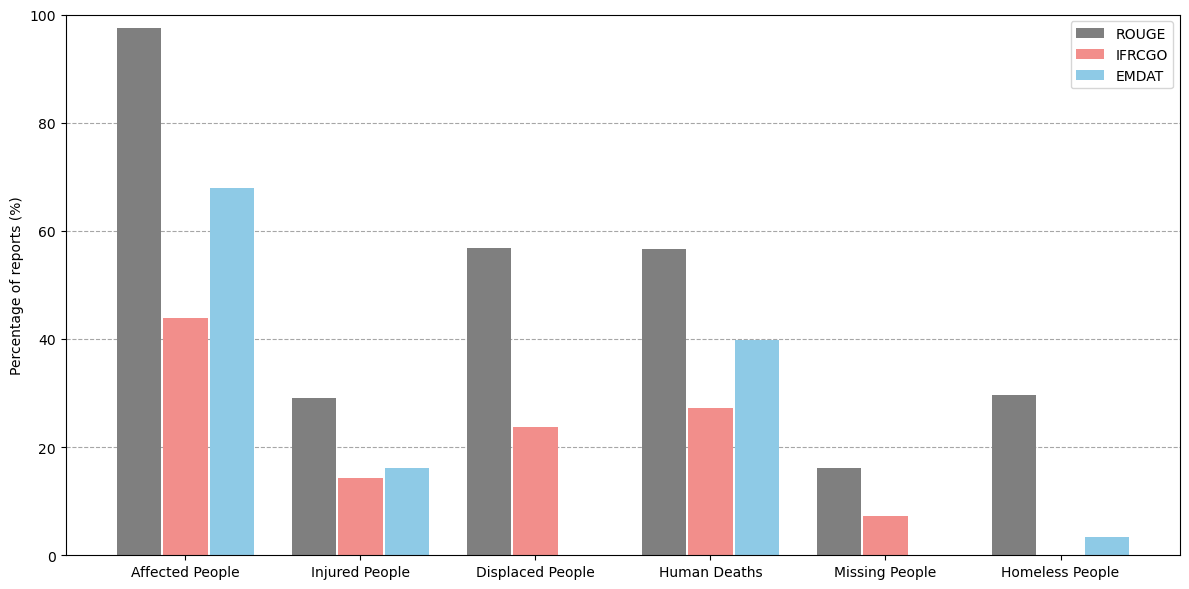

In [13]:
impact_types = list(mapping_impact_type.keys())
x = np.arange(len(impact_types))

# Plot sources in a fixed order when available in the new dictionary format
plot_sources = [s for s in ["ROUGE", "IFRCGO", "EMDAT"] if s in perc_report_with_impact]
width = 0.8 / max(len(plot_sources), 1)

fig, ax = plt.subplots(figsize=(12, 6))

# Colors aligned with the new source names
# colors = {
#     "ROUGE": "#cc2f2f",
#     "IFRCGO": "#5fbf84",
#     "EMDAT": "#5fa8d3",
# }

colors = {
    "ROUGE": "#d66a6a",
    "IFRCGO": "#54a77a",
    "EMDAT": "#4c78a8",
}

for i, source in enumerate(plot_sources):
    offset = (i - (len(plot_sources) - 1) / 2) * width
    bars = ax.bar(
        x + offset,
        perc_report_with_impact[source],
        width * 0.95,
        label=source,
        color=colors.get(source, "grey"),
    )

    # Add value labels above bars
    for bar in bars:
        height = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.1,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9,
        )

# Labels
ax.set_xticks(x)
ax.set_xticklabels(impact_types)
ax.set_ylabel("Percentage of reports (%)")
ax.legend()

for y in [20, 40, 60, 80]:
    ax.axhline(y=y, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, zorder=0)

ax.set_ylim(0, 100)

plt.tight_layout()
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.png", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.svg", format="svg", transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / "percentage_events_quanti_impact.pdf", format="pdf", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

## Bar Plot after event matching

In [16]:
nb_matched = {}

In [17]:
nb_matched = {}
nb_exact_match = {}
nb_no_match = {}
nb_no_external_impact = {}
df_matched_with_impact = {}

tolerance = 0.10

def compute_matching_metrics_from_linked_df(
    df_linked,
    source_name,
    value_col,
    impact_subtypes,
    tolerance=0.10,
    reference_col="ROUGE",
    compare_col="IFRCGO",
    compare_prefix=None,
 ):
    """
    Compute matching metrics per impact subtype from a linked dataframe.

    Expected columns in df_linked:
    - appealCode
    - impactSubtype
    - impactValue_final
    - external value column (value_col)
    - optional comparison column (compare_col), e.g. EMDAT vs IFRCGO in linked ALL
    """
    out_nb_matched = []
    out_nb_exact_match = []
    out_nb_no_external_impact = []
    out_df_matched_with_impact = pd.DataFrame()

    for impactSubtype in impact_subtypes:
        df_sub = df_linked.loc[df_linked["impactSubtype"] == impactSubtype].copy()

        n_before = len(df_sub)
        if value_col not in df_sub.columns:
            out_nb_matched.append(0)
            out_nb_exact_match.append(0)
            out_nb_no_external_impact.append(n_before)
            continue

        # Only compute ROUGE-vs-external rel_diff when both values exist
        df_sub = df_sub.dropna(subset=["impactValue_final", value_col])
        n_after = len(df_sub)

        if n_after == 0:
            out_nb_matched.append(0)
            out_nb_exact_match.append(0)
            out_nb_no_external_impact.append(n_before)
            continue

        # Loop over the reference columns
        for ref_col in reference_col :
            # Add selection of relevant columns
            if ref_col=="ROUGE" :
                col_impactValue = "impactValue_final"
            else :
                col_impactValue = source_cfg[ref_col]["value_col"]

            # External vs reference col
            df_sub[f"abs_diff_{ref_col}"] = (df_sub[col_impactValue] - df_sub[value_col]).abs()
            df_sub[f"rel_diff_{ref_col}"] = ((df_sub[col_impactValue] - df_sub[value_col])/ df_sub[value_col].replace(0, np.nan))
            df_sub[f"abs_rel_diff_{ref_col}"] = df_sub[f"rel_diff_{ref_col}"].abs()
            df_sub[f"{source_name}/{ref_col}"] = df_sub[value_col] / df_sub[col_impactValue].replace(
                0, np.nan
            )
            df_sub[f"{ref_col}/{source_name}"] = df_sub[col_impactValue] / df_sub[value_col].replace(
                0, np.nan
            )
            df_sub[f"match_{ref_col}"] = df_sub[f"abs_rel_diff_{ref_col}"] <= tolerance

            out_df_matched_with_impact = pd.concat(
                [out_df_matched_with_impact, df_sub],
                axis=0,
                ignore_index=True,
            )

            out_nb_no_external_impact.append(n_before - n_after)
            out_nb_matched.append(df_sub["appealCode"].nunique())
            out_nb_exact_match.append(df_sub.loc[df_sub[f"match_{ref_col}"], "appealCode"].nunique())

    return {
        "nb_matched": out_nb_matched,
        "nb_exact_match": out_nb_exact_match,
        "nb_no_external_impact": out_nb_no_external_impact,
        "df_matched_with_impact": out_df_matched_with_impact,
    }


# Run for linked IFRCGO and EMDAT using their standardized impact value columns
source_cfg = {
    "IFRCGO": {"linked_key": "IFRCGO", "value_col": "IFRCGO_impactValue"},
    "EMDAT": {"linked_key": "EMDAT", "value_col": "EMDAT_impactValue"},
    # "ROUGE" : {"linked_key": "ROUGE", "value_col": "impactValue_final"},
    # "ALL": {
    #     "linked_key": "ALL",
    #     "value_col": "EMDAT_impactValue",
    #     "compare_col": "IFRCGO_impactValue",
    #     "compare_prefix": "EMDAT_vs_IFRCGO",
    # },
}
for source_name, cfg in source_cfg.items():
    metrics = compute_matching_metrics_from_linked_df(
        df_linked=df_llm_all_geo_grp_linked["ALL"],
        source_name=source_name,
        value_col=cfg["value_col"],
        impact_subtypes=list(mapping_impact_type.keys()),
        tolerance=tolerance,
        reference_col=["ROUGE", "EMDAT"],
        compare_col=cfg.get("compare_col"),
        compare_prefix=cfg.get("compare_prefix"),
    )

    nb_matched[source_name] = metrics["nb_matched"]
    nb_exact_match[source_name] = metrics["nb_exact_match"]
    nb_no_external_impact[source_name] = metrics["nb_no_external_impact"]
    df_matched_with_impact[source_name] = metrics["df_matched_with_impact"]
    df_matched_with_impact["ALL"] = metrics["df_matched_with_impact"]

In [17]:
# x = np.arange(len(mapping_impact_type.keys()))  # positions for bars
# width = 0.25  # bar width

# fig, ax = plt.subplots(figsize=(12,6))

# # Define colors
# colors = {
#     "ifrc_monty": ["skyblue", "dodgerblue"],
#     "emdat": ["lightgreen", "green"],
#     "ifrc_go": ["lightcoral", "brown"],
# }

# for i, external_source in enumerate(["ifrc_go", "emdat"]):
#     # Base bars ("all")
#     bars_all = ax.bar(
#         x + (i-1)*width,
#         nb_matched[external_source],
#         width,
#         label=external_source + " - all",
#         color=colors[external_source][0],
#     )

#     # Add stacked bar ("no external impact") on top of "all"
#     ax.bar(
#         x + (i-1)*width,
#         nb_no_external_impact[external_source],
#         width,
#         bottom=nb_matched[external_source],
#         label=external_source + " - no impact",
#         color="lightgray",
#         # edgecolor="gray",
#     )

#     # "Perfect match" bars
#     ax.bar(
#         x + (i-1)*width,
#         nb_exact_match[external_source],
#         width,
#         label=external_source + " - perfect match",
#         color=colors[external_source][1],
#         alpha=0.9,
#     )

# # Target lines
# total_bar_width = 3*width
# for xi, y in zip(x, nb_extracted):
#     ax.hlines(
#         y=y,
#         xmin=xi - total_bar_width/2,
#         xmax=xi + total_bar_width/2,
#         colors='black',
#         linewidth=2,
#         label="LLM" if xi == 0 else ""
#     )

# # Labels and formatting
# ax.set_xticks(x)
# ax.set_xticklabels(mapping_impact_type.keys(), rotation=45, ha="right")
# ax.set_ylabel("Number of Appeals")
# ax.set_title("Appeal matching comparison (IFRC vs EMDAT)")
# ax.legend()
# plt.tight_layout()
# plt.show()

## Coefficient of variation 

In [18]:
df = df_llm_all_geo_grp_linked["ALL"][["impactSubtype","impactValue","EMDAT_impactValue","IFRCGO_impactValue",]].copy()

# Rename for convenience
df = df.rename(columns={"impactValue": "ROUGE", "EMDAT_impactValue": "EMDAT","IFRCGO_impactValue": "IFRCGO",})

# Keep only complete rows
df = df[df.impactSubtype.isin(impact_subtypes)]

# Replace the quantitative values of 0 with NaN to avoid issues in log scale plotting
for col in ["ROUGE", "EMDAT", "IFRCGO"]:
    df[col] = df[col].replace(0, np.nan)

In [19]:
sources = ["ROUGE", "EMDAT", "IFRCGO"]
complete_mask = df[sources].notna().all(axis=1)

# Mean/std/CV
df["mean"] = df[sources].mean(axis=1, skipna=True)
df["std"] = df[sources].std(axis=1, skipna=True)

# Avoid division by zero
df["cv"] = np.where(df["mean"] != 0, df["std"] / df["mean"], np.nan)

# Squared deviations
for s in sources:
    df[f"{s}_sqdev"] = (df[s] - df["mean"])**2

sqdev_cols = [f"{s}_sqdev" for s in sources]

# Total variance contribution
df["total_sqdev"] = df[sqdev_cols].sum(axis=1)

for s in sources:
    df[f"{s}_contrib"] = (df[f"{s}_sqdev"] / df["total_sqdev"])

# Dominant contributor
contrib_cols = [f"{s}_contrib" for s in sources]
df.loc[complete_mask, "dominant_source"] = (df.loc[complete_mask, contrib_cols].idxmax(axis=1).str.replace("_contrib", ""))

# df["dominant_source"] = (df[contrib_cols].idxmax(axis=1).str.replace("_contrib", ""))

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_21992\521365953.py:25: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  df.loc[complete_mask, "dominant_source"] = (df.loc[complete_mask, contrib_cols].idxmax(axis=1).str.replace("_contrib", ""))


In [26]:
def get_missing_combo_color(row, combo_color_map):
    emdat_missing = pd.isna(row.get("EMDAT")) or row.get("EMDAT") == ""
    ifrc_missing = pd.isna(row.get("IFRCGO")) or row.get("IFRCGO") == ""

    # ROUGE + EMDAT only (IFRCGO missing)
    if not emdat_missing and ifrc_missing:
        return combo_color_map["ROUGE + EM-DAT"]

    # ROUGE + IFRCGO only (EMDAT missing)
    if not ifrc_missing and emdat_missing:
        return combo_color_map["ROUGE + IFRC GO"]

    # fallback (both present or both missing)
    return "#b0b0b0"

KeyError: 'ROUGE + IFRCGO'

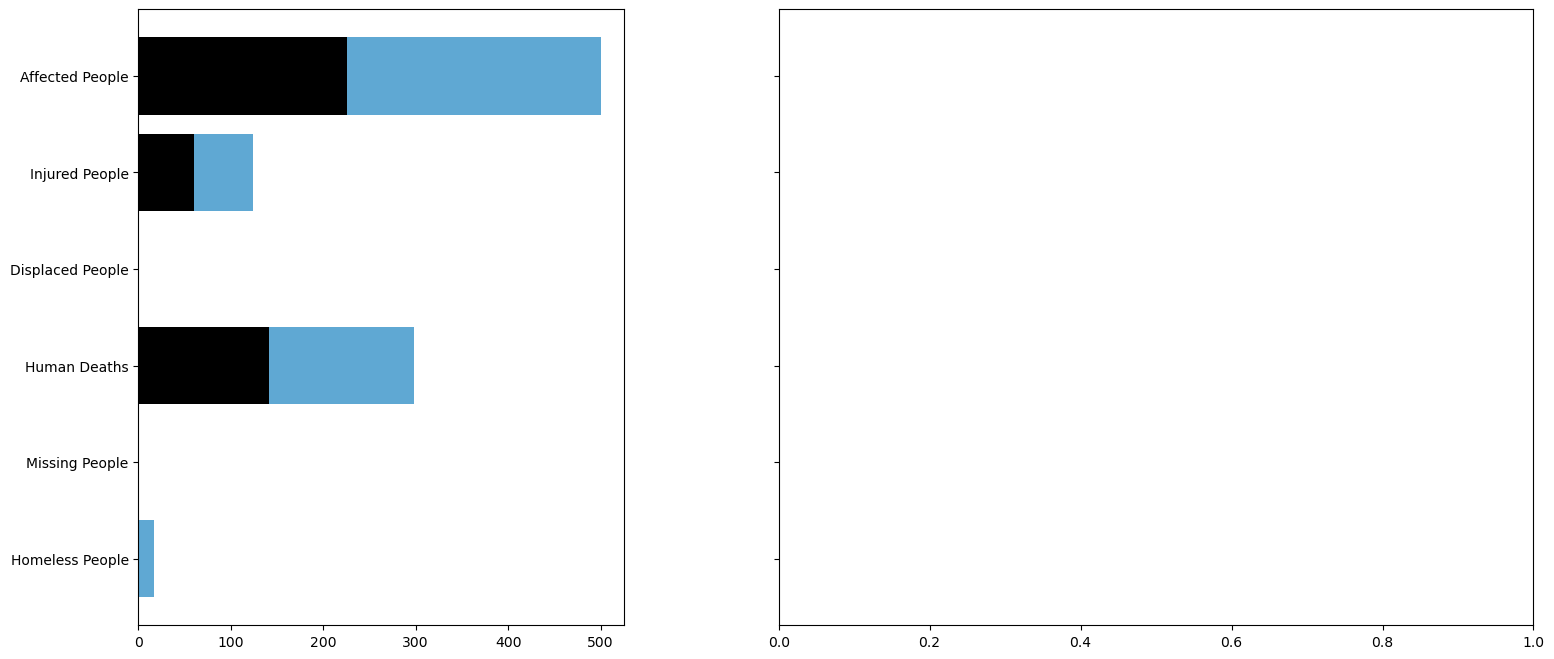

In [28]:
# ============================================================
# Colors
# ============================================================

source_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#4c9a5f",
}

# combo_color_map = {
#     "All": "#b0b0b0",
#     "ROUGE + EMDAT": "#f7b2b2",
#     "ROUGE + IFRCGO": "#f06a6a",
#     "ROUGE only": "#cc2f2f",
# }
combo_color_map = {
    "All": "black",            # deeper dark brown-red
    "ROUGE + EMDAT": "#5fa8d3",  # clearer blue
    "ROUGE + IFRC GO": "#5fbf84", # clearer green
    "ROUGE only": "#cc2f2f",
}

combo_hatch_map = {
    "All": "",
    "ROUGE + EMDAT": "",
    "ROUGE + IFRC GO": "",
    "ROUGE only": "",
}

# ============================================================
# Category ordering
# ============================================================

order = impact_subtypes[::-1]  # (df.groupby("impactSubtype")["cv"].median().sort_values().index)
categories = list(order)
df["impactSubtype"] = pd.Categorical(df["impactSubtype"], categories=categories, ordered=True)

# ============================================================
# Quantitative value availability by impact subtype
# ============================================================

presence = df[["ROUGE", "EMDAT", "IFRCGO"]].notna().copy()
presence["impactSubtype"] = df["impactSubtype"].astype(str)
presence = presence.dropna(subset=["impactSubtype"])

combo_masks = {
    "All": presence["ROUGE"] & presence["EMDAT"] & presence["IFRCGO"],
    "ROUGE + EMDAT": presence["ROUGE"] & presence["EMDAT"] & ~presence["IFRCGO"],
    "ROUGE + IFRCGO": presence["ROUGE"] & ~presence["EMDAT"] & presence["IFRCGO"],
    "ROUGE only": presence["ROUGE"] & ~presence["EMDAT"] & ~presence["IFRCGO"],
}
combo_order = list(combo_masks.keys())

combo_labels = pd.Series(index=presence.index, dtype="object")
for label in combo_order:
    combo_labels.loc[combo_masks[label]] = label

combo_counts_by_subtype = (
    presence.assign(combo=combo_labels)
    .dropna(subset=["combo"])
    .groupby(["impactSubtype", "combo"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=categories, columns=combo_order, fill_value=0)
)

# ============================================================
# Figure
# ============================================================

fig, (ax_counts, ax) = plt.subplots(1, 2, figsize=(18, 8), sharey=True,gridspec_kw={"width_ratios": [1.35, 2.1], "wspace": 0.25} )

# ============================================================
# Left panel: quantitative-value counts per impact subtype
# ============================================================

left_accum = np.zeros(len(categories), dtype=float)
stack_styles = {
    "All": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE + EMDAT": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE + IFRC GO": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE only": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
}

for combo in combo_order:
    values = combo_counts_by_subtype[combo].reindex(categories).values
    ax_counts.barh(
        categories,
        values,
        left=left_accum,
        color=combo_color_map[combo],
        hatch=combo_hatch_map[combo],
        alpha=stack_styles[combo]["alpha"],
        label=combo,
    )
    left_accum += values

for i, total in enumerate(left_accum):
    if total > 0:
        ax_counts.text(
            total + max(left_accum.max() * 0.01, 0.5),
            i,
            f"{int(total)}",
            va="center",
            fontsize=10,
        )

ax_counts.set_xlabel("Number of events with quantitative value")
ax_counts.set_ylabel("")
ax_counts.set_title("(a)", loc="left")
ax_counts.grid(axis="x", alpha=0.25, color="#cc6666")
ax_counts.spines["top"].set_visible(False)
ax_counts.spines["right"].set_visible(False)
ax_counts.legend(
    title="Quantitative value availability",
    bbox_to_anchor=(0.5, -0.2),
    loc="lower center",
    ncols=4,
    frameon=False,
)

# ============================================================
# Right panel: CV distribution
# ============================================================

boxplot_data = [df.loc[df["impactSubtype"] == cat, "cv"].dropna() for cat in categories]

bp = ax.boxplot(
    boxplot_data,
    vert=False,
    positions=np.arange(len(categories)),
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for patch in bp["boxes"]:
    patch.set_facecolor("#fffdfd")
    patch.set_alpha(0.95)
    patch.set_edgecolor("black")

rng = np.random.default_rng(42)
y_map = {cat: i for i, cat in enumerate(categories)}

sub_missing = df[df["dominant_source"].isna()]
y_missing = np.array([y_map[v] for v in sub_missing["impactSubtype"]])
y_missing_jitter = y_missing + rng.uniform(-0.15, 0.15, len(y_missing))

ax.scatter(
    sub_missing["cv"],
    y_missing_jitter,
    s=35,
    alpha=0.55,
    color="#b0b0b0",
    label="None",
    zorder=4,
)

for source in ["ROUGE", "EMDAT", "IFRCGO"]:
    sub = df[df["dominant_source"] == source]
    y = np.array([y_map[v] for v in sub["impactSubtype"]])
    y_jitter = y + rng.uniform(-0.20, 0.20, len(y))

    ax.scatter(
        sub["cv"],
        y_jitter,
        s=35,
        alpha=0.75,
        color=source_colors[source],
        label=source,
        zorder=3,
    )

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories)
ax.set_xlabel("Coefficient of variation (CV)")
ax.grid(axis="x", alpha=0.22, color="black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(title="Largest variance contributor",
          bbox_to_anchor=(0.5, -0.2),
          loc="lower center",
          ncols=4,
          frameon=False,)
ax.set_title("(b)", loc="left")

plt.tight_layout()
plt.show()

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_21992\1320491580.py:287: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


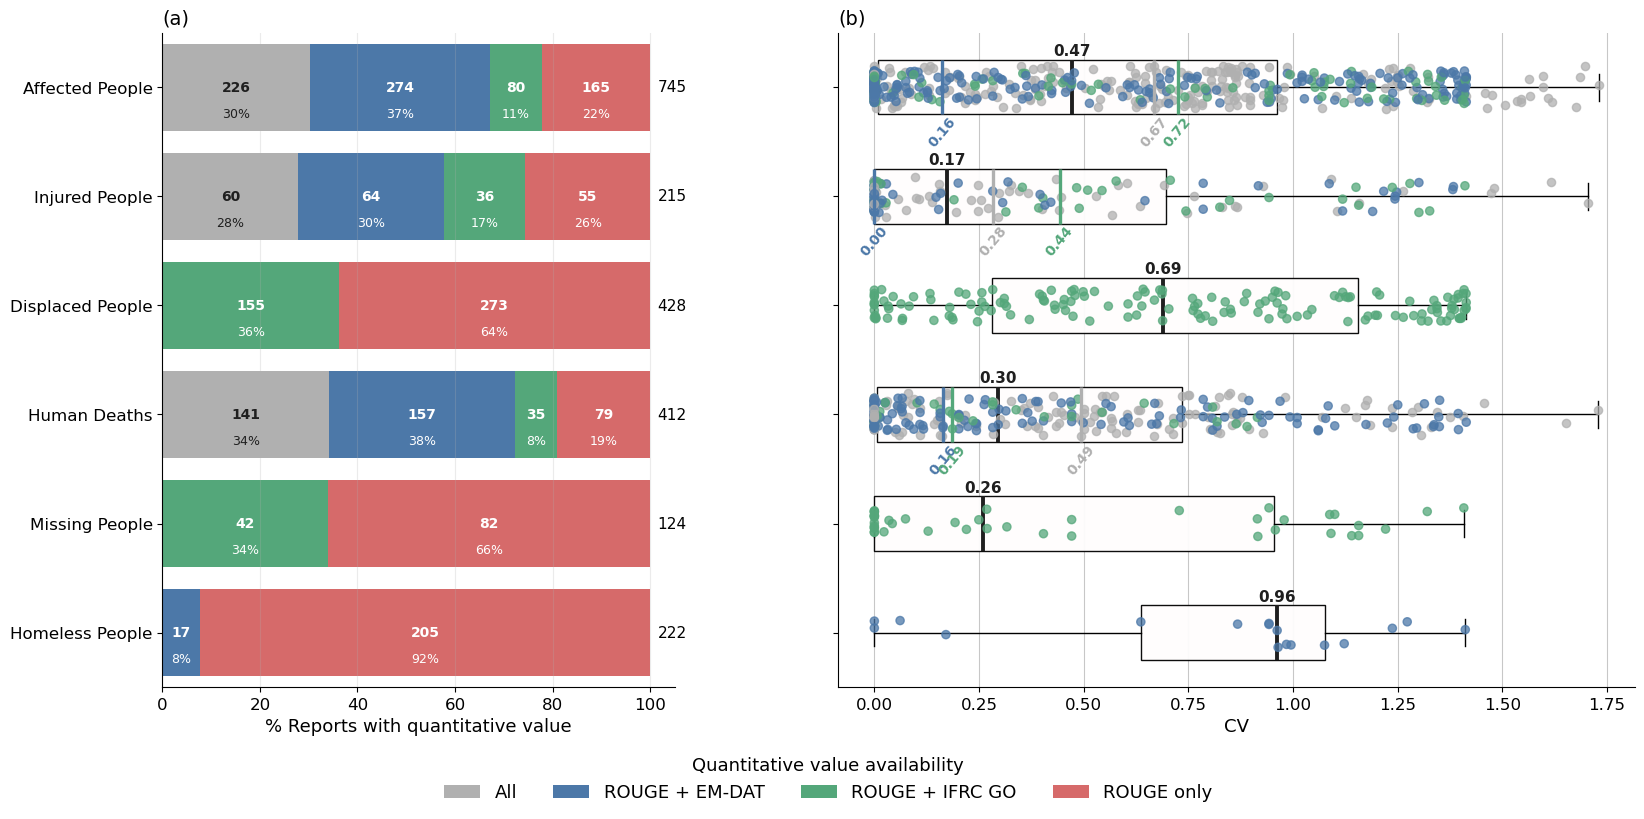

In [32]:
# Plot comparaison of quanti records and values
# ============================================================
# Typography
# ============================================================

title_fs = 14
label_fs = 13
tick_fs = 12
legend_fs = 13
count_fs = 11
annot_fs = 11

# ============================================================
# Colors
# ============================================================

combo_color_map = {
    "All": "#b0b0b0",            # light-medium gray (clean neutral)
    "ROUGE + EM-DAT": "#4c78a8",  # softened blue (less deep)
    "ROUGE + IFRC GO": "#54a77a", # softened green (balanced)
    "ROUGE only": "#d66a6a",     # softened red (less aggressive than #c53030)
}

# ============================================================
# Category ordering
# ============================================================

order = impact_subtypes[::-1]  # (df.groupby("impactSubtype")["cv"].median().sort_values().index)
categories = list(order)
df["impactSubtype"] = pd.Categorical(df["impactSubtype"], categories=categories, ordered=True)

# ============================================================
# Quantitative value availability by impact subtype
# ============================================================

presence = df[["ROUGE", "EMDAT", "IFRCGO"]].notna().copy()
presence["impactSubtype"] = df["impactSubtype"].astype(str)
presence = presence.dropna(subset=["impactSubtype"])

combo_masks = {
    "All": presence["ROUGE"] & presence["EMDAT"] & presence["IFRCGO"],
    "ROUGE + EM-DAT": presence["ROUGE"] & presence["EMDAT"] & ~presence["IFRCGO"],
    "ROUGE + IFRC GO": presence["ROUGE"] & ~presence["EMDAT"] & presence["IFRCGO"],
    "ROUGE only": presence["ROUGE"] & ~presence["EMDAT"] & ~presence["IFRCGO"],
}
combo_order = list(combo_masks.keys())

combo_labels = pd.Series(index=presence.index, dtype="object")
for label in combo_order:
    combo_labels.loc[combo_masks[label]] = label

df["availability_combo"] = combo_labels.reindex(df.index)

combo_counts_by_subtype = (
    presence.assign(combo=combo_labels)
    .dropna(subset=["combo"])
    .groupby(["impactSubtype", "combo"])
    .size()
    .unstack(fill_value=0)
    .reindex(index=categories, columns=combo_order, fill_value=0)
)

# Convert counts to percentages so the x-axis is 0-100%.
combo_percent_by_subtype = combo_counts_by_subtype.div(combo_counts_by_subtype.sum(axis=1).replace(0, np.nan), axis=0).fillna(0) * 100

# ============================================================
# Figure
# ============================================================

fig, (ax_counts, ax) = plt.subplots(
    1,
    2,
    figsize=(19, 8.5),
    sharey=True,
    gridspec_kw={"width_ratios": [1.35, 2.1], "wspace": 0.25},
)

# ============================================================
# Left panel: quantitative-value counts per impact subtype
# ============================================================

left_accum = np.zeros(len(categories), dtype=float)
stack_styles = {
    "All": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE + EM-DAT": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE + IFRC GO": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
    "ROUGE only": {"facecolor": "white", "edgecolor": "black", "alpha": 1.0, "linewidth": 0.8},
}

for combo in combo_order:
    pct_values = combo_percent_by_subtype[combo].reindex(categories).values
    raw_values = combo_counts_by_subtype[combo].reindex(categories).values

    ax_counts.barh(
        categories,
        pct_values,
        left=left_accum,
        color=combo_color_map[combo],
        alpha=stack_styles[combo]["alpha"],
        label=combo,
    )

    # Exact counts inside each segment, where percentages used to be shown.
    for i, (count_value, left, pct_value, total) in enumerate(zip(raw_values, left_accum, pct_values, combo_counts_by_subtype.sum(axis=1).reindex(categories).values)):
        if count_value > 0 and total > 0:
            # Exact count (original)
            ax_counts.text(
                left + pct_value / 2,
                i,
                f"{int(count_value)}",
                ha="center",
                va="center",
                fontsize=count_fs - 1,
                color="white" if combo != "All" else "#1f1f1f",
                fontweight="bold",
            )
            # Percentage below the exact count
            ax_counts.text(
                left + pct_value / 2,
                i - 0.18,
                f"{pct_value:.0f}%",
                ha="center",
                va="top",
                fontsize=count_fs - 2,
                color="white" if combo != "All" else "#1f1f1f",
            )

    left_accum += pct_values

for i, total in enumerate(combo_counts_by_subtype.sum(axis=1).reindex(categories).values):
    if total > 0:
        ax_counts.text(
            101.5,
            i,
            f"{int(total)}",
            va="center",
            fontsize=count_fs,
        )

ax_counts.set_xlabel("% Reports with quantitative value", fontsize=label_fs)
ax_counts.set_ylabel("")
ax_counts.set_title("(a)", loc="left", fontsize=title_fs)
ax_counts.grid(axis="x", alpha=0.25)
ax_counts.set_xlim(0, 105)
ax_counts.spines["top"].set_visible(False)
ax_counts.spines["right"].set_visible(False)
ax_counts.tick_params(axis="both", labelsize=tick_fs)
ax_counts.legend(
    title="Quantitative value availability",
    bbox_to_anchor=(1.3, -0.2),
    loc="lower center",
    ncols=4,
    frameon=False,
    fontsize=legend_fs,
    title_fontsize=legend_fs,
)

# ============================================================
# Right panel: CV distribution
# ============================================================

boxplot_data = [df.loc[df["impactSubtype"] == cat, "cv"].dropna() for cat in categories]

bp = ax.boxplot(
    boxplot_data,
    vert=False,
    positions=np.arange(len(categories)),
    widths=0.5,
    patch_artist=True,
    showfliers=False,
)

for patch in bp["boxes"]:
    patch.set_facecolor("#fffdfd")
    patch.set_alpha(0.95)
    patch.set_edgecolor("black")

# Emphasize the median with a darker, thicker line and annotate its value
for median_line, values, pos in zip(bp["medians"], boxplot_data, np.arange(len(categories))):
    median_value = float(np.nanmedian(values)) if len(values) > 0 else np.nan
    median_line.set_color("#1f1f1f")
    median_line.set_linewidth(2.8)
    if np.isfinite(median_value):
        ax.text(
            median_value,
            pos + 0.4,
            f"{median_value:.2f}",
            ha="center",
            va="top",
            rotation=0,
            fontsize=annot_fs,
            color="#1f1f1f",
            fontweight="bold",
            zorder=6,
        )

# Additional subset medians (only for categories quantified in all databases)
subset_median_categories = {"Affected People", "Injured People", "Human Deaths"}
subset_annot_combos = ["All", "ROUGE + EM-DAT", "ROUGE + IFRC GO", "ROUGE only"]

for pos, cat in enumerate(categories):
    if cat not in subset_median_categories:
        continue

    y_base = pos
    y_step = 0.12
    marker_half_height = 0.25

    for j, combo in enumerate(subset_annot_combos):
        med_vals = df.loc[
            (df["impactSubtype"] == cat) & (df["availability_combo"] == combo),
            "cv",
        ].dropna()

        if len(med_vals) == 0:
            continue

        med = float(np.nanmedian(med_vals))
        y = y_base# + j * y_step

        # Vertical marker line at subset median (same idea as boxplot median line)
        ax.vlines(
            med,
            y - marker_half_height,
            y + marker_half_height,
            color=combo_color_map[combo],
            linewidth=2.4,
            zorder=7,
        )

        # Numeric value above the median marker line
        ax.text(
            med,
            y - marker_half_height,
            f"{med:.2f}",
            ha="center",
            va="top",
            rotation=50,
            fontsize=annot_fs - 1,
            color=combo_color_map[combo],
            fontweight="bold",
            zorder=8,
        )

rng = np.random.default_rng(42)
y_map = {cat: i for i, cat in enumerate(categories)}

sub_missing = df[df["dominant_source"].isna()]
y_missing = np.array([y_map[v] for v in sub_missing["impactSubtype"]])
y_missing_jitter = y_missing + rng.uniform(-0.15, 0.15, len(y_missing))

colors_missing = sub_missing.apply(get_missing_combo_color, axis=1, combo_color_map=combo_color_map)
ax.scatter(
    sub_missing["cv"],
    y_missing_jitter,
    s=35,
    alpha=0.75,
    color=colors_missing,
    label="None",
    zorder=4,
)

for source in ["ROUGE", "EMDAT", "IFRCGO"]:
    sub = df[df["dominant_source"] == source]
    y = np.array([y_map[v] for v in sub["impactSubtype"]])
    y_jitter = y + rng.uniform(-0.20, 0.20, len(y))

    ax.scatter(
        sub["cv"],
        y_jitter,
        s=35,
        alpha=0.75,
        color=combo_color_map["All"],
        label=source,
        zorder=3,
    )

ax.set_yticks(range(len(categories)))
ax.set_yticklabels(categories, fontsize=label_fs)
ax.set_xlabel("CV", fontsize=label_fs)
ax.grid(axis="x", alpha=0.22, color="black")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.tick_params(axis="x", labelsize=tick_fs)
ax.tick_params(axis="y", labelsize=tick_fs)
ax.set_title("(b)", loc="left", fontsize=title_fs)
plt.tight_layout()

fig.savefig(path_save_fig / f"quantitative_perc_comparison_number_value.png",
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"quantitative_perc_comparison_number_value.svg",
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
plt.show()

## Bar plot relative error 

KeyError: 'rel_diff'

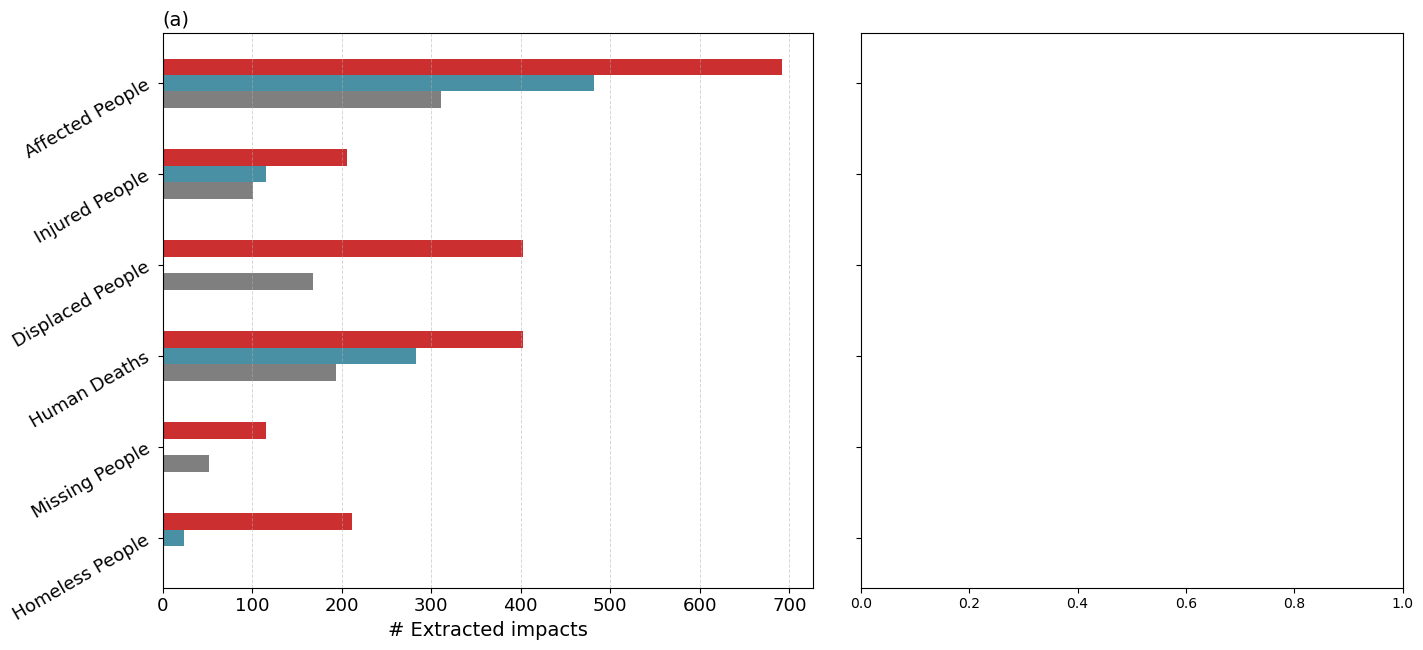

In [24]:
# (a)-(b) Two-column aligned plot: report counts and rel_diff distributions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# Toggle to include IFRC Monty in both panels
INCLUDE_IFRC_MONTY = False

# Font sizes
tick_fs = 13
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
n_types = len(impact_types)
y = np.arange(n_types)

# Keep labels identical across both subplots for perfect row alignment
impact_labels = impact_types

# Pick IFRC key available in both dictionaries (prefer IFRCGO)
if "IFRCGO" in nb_matched and "IFRCGO" in df_matched_with_impact:
    ifrc_key = "IFRCGO"
else:
    ifrc_key = "IFRC MONTY"

# External sources to compare
ext_sources = ["EMDAT", ifrc_key]
if INCLUDE_IFRC_MONTY and "IFRC MONTY" in nb_matched and "IFRC MONTY" in df_matched_with_impact and "IFRC MONTY" not in ext_sources:
    ext_sources.append("IFRC MONTY")

# Build left-panel series (ROUGE + external sources)
left_series = ["ROUGE"] + ext_sources

# Dynamic lane spacing: keep all sources aligned across both panels
bar_h = 0.18
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary
counts_map = {
    "ROUGE": np.array(impact_count_summary['ROUGE_count'].values, dtype=float),
    "EMDAT": np.array(impact_count_summary['EMDAT_count'].values, dtype=float),
    "IFRCGO": np.array(impact_count_summary['IFRCGO_count'].values, dtype=float),
    "IFRC MONTY": np.array(
        impact_count_summary['IFRC MONTY_count'].values
        if 'IFRC MONTY_count' in impact_count_summary.columns
        else [0] * n_types,
        dtype=float
    ),
}

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.2, 1.0], "wspace": 0.08},
    sharey=True,
)

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "IFRC MONTY": "#b08968",
}
bar_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "IFRC MONTY": "IFRC MONTY",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=bar_labels[s],
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=30, ha="right")
# ax_a.set_ylabel("Impact subtype")
ax_a.invert_yaxis()
ax_a.set_xlabel("# Extracted impacts", fontsize=tick_fs+1)
ax_a.set_title("(a)", fontsize=tick_fs+1, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="both", labelsize=tick_fs)

# =====================
# (b) Horizontal boxplot of rel_diff
# =====================
box_h = bar_h * 0.85
box_style = {
    "EMDAT": {"face": "#4a90a4", "edge": "#1f5f78"},
    "IFRCGO": {"face": "#7f7f7f", "edge": "#4d4d4d"},
    "IFRC MONTY": {"face": "#b08968", "edge": "#7f5539"},
}

for s in ext_sources:
    box_vals = []
    box_pos = []

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_matched_with_impact.get(s, pd.DataFrame())
            .loc[lambda d: d["impactSubtype"] == impact_type, "rel_diff"]
            .dropna()
            .values
        )

        if len(vals) > 0:
            box_vals.append(vals)
            box_pos.append(y[i] + offset_map[s])

    if box_vals:
        bp = ax_b.boxplot(
            box_vals,
            positions=box_pos,
            vert=False,
            widths=box_h,
            patch_artist=True,
            showfliers=False,
        )

        for box in bp["boxes"]:
            box.set_facecolor(box_style[s]["face"])
            box.set_alpha(0.35)
            box.set_edgecolor(box_style[s]["edge"])
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        for whisker in bp["whiskers"]:
            whisker.set_color(box_style[s]["edge"])
        for cap in bp["caps"]:
            cap.set_color(box_style[s]["edge"])
ax_b.axvline(0, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xlabel(
    "Relative difference : " + r"$\frac{\mathrm{ROUGE-EXTERNAL}}{EXTERNAL}$",
    fontsize=tick_fs + 1
)
ax_b.set_title("(b)", fontsize=tick_fs+1, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)

# Keep one shared y definition while hiding labels on the right panel
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=20, ha="right")
ax_b.tick_params(axis="y", labelleft=False)

# Single shared legend for both subplots
shared_handles = [Patch(facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=bar_labels[s]) for s in left_series]
fig.legend(
    handles=shared_handles,
    loc="lower center",
    ncol=len(shared_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
    fontsize=legend_fs,
    title_fontsize=legend_fs,
 )
plt.tight_layout(rect=[0, 0.06, 1, 1])

#Save figure

# fig.savefig(path_save_fig / f"comparaison_external_events_values.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"comparaison_external_events_values.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_32128/2557041998.py:216: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


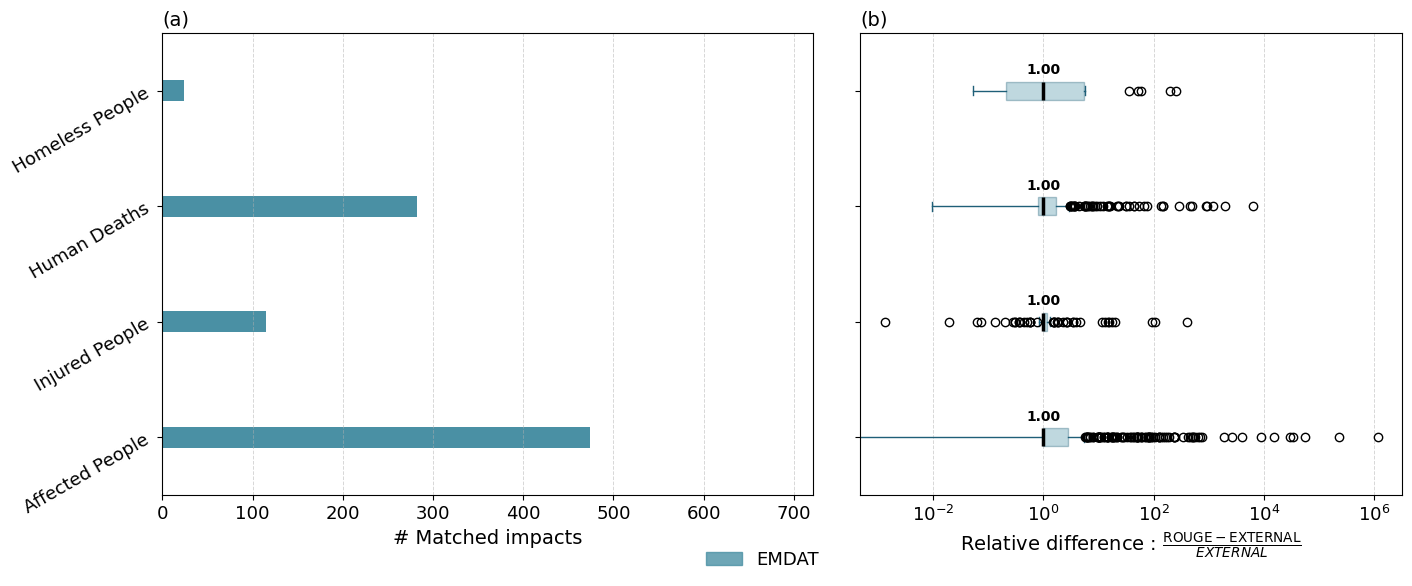

In [ ]:
# (a)-(b) Two-column aligned plot: report counts and rel_diff distributions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

# diff metric
diff_metric = "ratio2"
# Toggle to include IFRC Monty in both panels
INCLUDE_IFRC_MONTY = False

# Font sizes
tick_fs = 13
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
impact_counts = impact_count_summary.set_index("impactSubtype") if "impactSubtype" in impact_count_summary.columns else impact_count_summary
impact_types = [it for it in impact_types if impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0) > 0]
n_types = len(impact_types)
y = np.arange(n_types)

# Keep labels identical across both subplots for perfect row alignment
impact_labels = impact_types

# Pick IFRC key available in both dictionaries (prefer IFRCGO)
if "IFRCGO" in nb_matched and "IFRCGO" in df_matched_with_impact:
    ifrc_key = "IFRCGO"
else:
    ifrc_key = "IFRC MONTY"

# External sources to compare
ext_sources = ["EMDAT"]
if INCLUDE_IFRC_MONTY and "IFRC MONTY" in nb_matched and "IFRC MONTY" in df_matched_with_impact and "IFRC MONTY" not in ext_sources:
    ext_sources.append("IFRC MONTY")

# Build left-panel series (ROUGE + external sources)
# left_series = ["ROUGE"] + ext_sources

# Dynamic lane spacing: keep all sources aligned across both panels
bar_h = 0.18
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary
counts_map = {
    "ROUGE": np.array([impact_counts.get("ROUGE_count", pd.Series(dtype=float)).get(it, 0) for it in impact_types], dtype=float),
    "EMDAT": np.array([impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0) for it in impact_types], dtype=float),
    "IFRCGO": np.array([impact_counts.get("IFRCGO_count", pd.Series(dtype=float)).get(it, 0) for it in impact_types], dtype=float),
    "IFRC MONTY": np.array(
        [
            impact_counts.get("IFRC MONTY_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float
    ),
}

# Use the maximum Tukey upper fence across the plotted count series for the left panel
left_count_arrays = [counts_map[s] for s in left_series if s in counts_map]
left_tukey_limits = []
for values in left_count_arrays:
    if len(values) == 0:
        continue
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1
    left_tukey_limits.append(q3 + 1.5 * iqr)

if left_tukey_limits:
    left_x_lim = float(np.nanmax(left_tukey_limits))
    if not np.isfinite(left_x_lim) or left_x_lim <= 0:
        left_x_lim = 1.0
else:
    left_x_lim = 1.0

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.2, 1.0], "wspace": 0.08},
    sharey=True,
)

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "IFRC MONTY": "#b08968",
}
bar_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "IFRC MONTY": "IFRC MONTY",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=bar_labels[s],
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=30, ha="right")
# ax_a.set_ylabel("Impact subtype")
ax_a.invert_yaxis()
ax_a.set_xlabel("# Matched impacts", fontsize=tick_fs+1)
ax_a.set_title("(a)", fontsize=tick_fs+1, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="both", labelsize=tick_fs)
ax_a.set_xlim(0, left_x_lim * 1.05)

# =====================
# (b) Horizontal boxplot of rel_diff (constrained to -5 to 5)
# =====================
box_h = bar_h * 0.85
box_style = {
    "EMDAT": {"face": "#4a90a4", "edge": "#1f5f78"},
    "IFRCGO": {"face": "#7f7f7f", "edge": "#4d4d4d"},
    "IFRC MONTY": {"face": "#b08968", "edge": "#7f5539"},
}

for s in ext_sources:
    box_vals = []
    box_pos = []
    median_vals = []

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_matched_with_impact.get(s, pd.DataFrame())
            .loc[lambda d: d["impactSubtype"] == impact_type, diff_metric]
            .dropna()
            .values
        )

        # Clip values to [-5, 5] range
        #vals = np.clip(vals, -5, 5)

        if len(vals) > 0:
            box_vals.append(vals)
            box_pos.append(y[i] + offset_map[s])
            median_vals.append(np.median(vals))
        else:
            median_vals.append(np.nan)

    if box_vals:
        bp = ax_b.boxplot(
            box_vals,
            positions=box_pos,
            vert=False,
            widths=box_h,
            patch_artist=True,
            showfliers=True,
        )

        for box in bp["boxes"]:
            box.set_facecolor(box_style[s]["face"])
            box.set_alpha(0.35)
            box.set_edgecolor(box_style[s]["edge"])
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(2.5)  # Thicker median line
        for whisker in bp["whiskers"]:
            whisker.set_color(box_style[s]["edge"])
        for cap in bp["caps"]:
            cap.set_color(box_style[s]["edge"])

        # Add median value labels
        for pos, med_val in zip(box_pos, median_vals):
            if not np.isnan(med_val):
                ax_b.text(med_val, pos + 0.12, f'{med_val:.2f}',
                         fontsize=10, ha='center', va='bottom',
                         fontweight='bold', color='black')

ax_b.axvline(0, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xlabel(
    "Relative difference : " + r"$\frac{\mathrm{ROUGE-EXTERNAL}}{EXTERNAL}$",
    fontsize=tick_fs + 1
)
ax_b.set_title("(b)", fontsize=tick_fs+1, loc="left")
ax_b.set_xscale("log")

ax_b.tick_params(axis="x", labelsize=tick_fs)
# ax_b.set_xlim(-1, x_lim)
ax_b.set_ylim(-0.5, n_types - 0.5)

# Keep one shared y definition while hiding labels on the right panel
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=20, ha="right")
ax_b.tick_params(axis="y", labelleft=False)

# Single shared legend for both subplots
shared_handles = [Patch(facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=bar_labels[s]) for s in ext_sources]
fig.legend(
    handles=shared_handles,
    loc="lower center",
    ncol=len(shared_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
    fontsize=legend_fs,
    title_fontsize=legend_fs,
 )
plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save figure

# fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_only.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_only.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)

/var/folders/y5/t1z41tgj7dv50sm2_29dn8740000gp/T/ipykernel_32128/4189706891.py:247: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


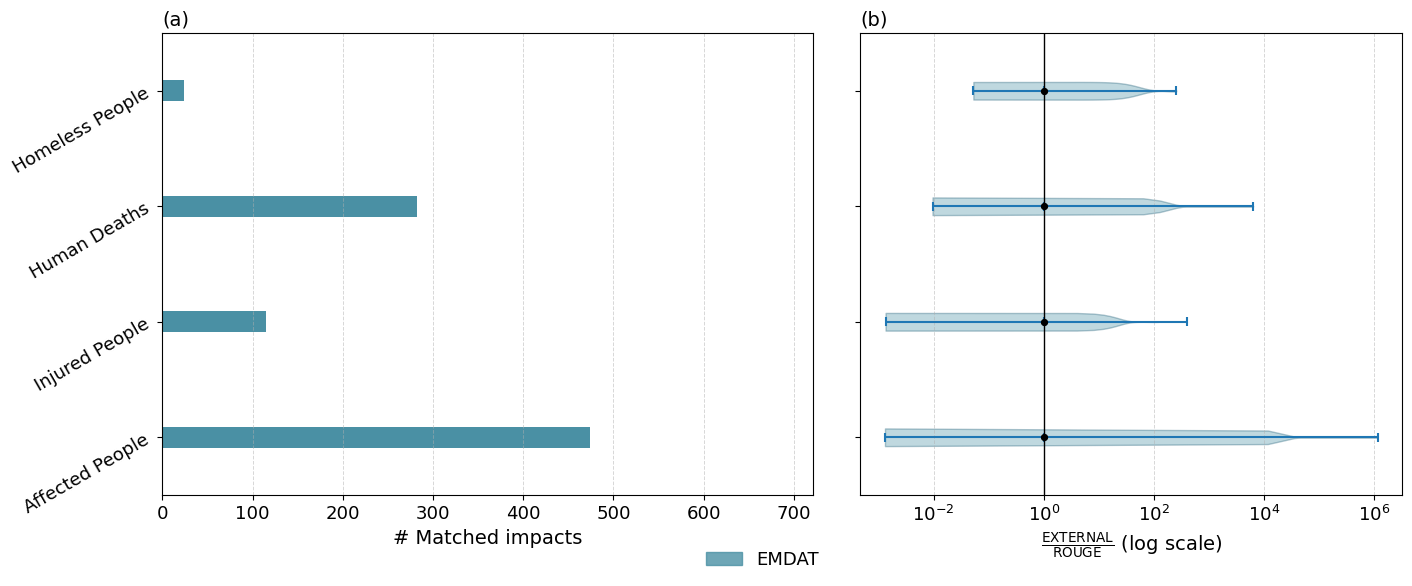

In [ ]:
# (a)-(b) Two-column aligned plot: report counts and rel_diff distributions
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import gaussian_kde

# Toggle to include IFRC Monty in both panels
INCLUDE_IFRC_MONTY = False

diff_metric = "ratio2"

# Font sizes
tick_fs = 13
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
impact_counts = (
    impact_count_summary.set_index("impactSubtype")
    if "impactSubtype" in impact_count_summary.columns
    else impact_count_summary
)
impact_types = [
    it
    for it in impact_types
    if impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0) > 0
]
n_types = len(impact_types)
y = np.arange(n_types)

# Keep labels identical across both subplots for perfect row alignment
impact_labels = impact_types

# Pick IFRC key available in both dictionaries (prefer IFRCGO)
if "IFRCGO" in nb_matched and "IFRCGO" in df_matched_with_impact:
    ifrc_key = "IFRCGO"
else:
    ifrc_key = "IFRC MONTY"

# External sources to compare
ext_sources = ["EMDAT"]
if (
    INCLUDE_IFRC_MONTY
    and "IFRC MONTY" in nb_matched
    and "IFRC MONTY" in df_matched_with_impact
    and "IFRC MONTY" not in ext_sources
):
    ext_sources.append("IFRC MONTY")

# Build left-panel series (ROUGE + external sources)
left_series = ext_sources

# Dynamic lane spacing: keep all sources aligned across both panels
bar_h = 0.18
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary
counts_map = {
    "ROUGE": np.array(
        [
            impact_counts.get("ROUGE_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "EMDAT": np.array(
        [
            impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "IFRCGO": np.array(
        [
            impact_counts.get("IFRCGO_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "IFRC MONTY": np.array(
        [
            impact_counts.get("IFRC MONTY_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
}

# Use the maximum Tukey upper fence across the plotted count series for the left panel
left_count_arrays = [counts_map[s] for s in left_series if s in counts_map]
left_tukey_limits = []
for values in left_count_arrays:
    if len(values) == 0:
        continue
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1
    left_tukey_limits.append(q3 + 1.5 * iqr)

if left_tukey_limits:
    left_x_lim = float(np.nanmax(left_tukey_limits))
    if not np.isfinite(left_x_lim) or left_x_lim <= 0:
        left_x_lim = 1.0
else:
    left_x_lim = 1.0

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.2, 1.0], "wspace": 0.08},
    sharey=True,
)

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "IFRC MONTY": "#b08968",
}
bar_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "IFRC MONTY": "IFRC MONTY",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=bar_labels[s],
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=30, ha="right")
# ax_a.set_ylabel("Impact subtype")
ax_a.invert_yaxis()
ax_a.set_xlabel("# Matched impacts", fontsize=tick_fs + 1)
ax_a.set_title("(a)", fontsize=tick_fs + 1, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="both", labelsize=tick_fs)
ax_a.set_xlim(0, left_x_lim * 1.05)

# =====================
# (b) Horizontal violin plot on log scale
# =====================
box_h = bar_h * 0.85
box_style = {
    "EMDAT": {"face": "#4a90a4", "edge": "#1f5f78"},
    "IFRCGO": {"face": "#7f7f7f", "edge": "#4d4d4d"},
    "IFRC MONTY": {"face": "#b08968", "edge": "#7f5539"},
}

for s in ext_sources:
    violin_vals = []
    violin_pos = []
    median_vals = []

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_matched_with_impact.get(s, pd.DataFrame())
            .loc[lambda d: d["impactSubtype"] == impact_type, diff_metric]
            .dropna()
            .values
        )

        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]

        if len(vals) > 0:
            violin_vals.append(vals)
            violin_pos.append(y[i] + offset_map[s])
            median_vals.append(np.median(vals))
        else:
            median_vals.append(np.nan)

    if violin_vals:
        vp = ax_b.violinplot(
            violin_vals,
            positions=violin_pos,
            vert=False,
            widths=box_h,
            showmeans=False,
            showmedians=True,
            showextrema=True,
        )

        for body in vp["bodies"]:
            body.set_facecolor(box_style[s]["face"])
            body.set_edgecolor(box_style[s]["edge"])
            body.set_alpha(0.35)

        for pos, med_val in zip(violin_pos, median_vals):
            if np.isfinite(med_val):
                ax_b.scatter(
                    med_val,
                    pos,
                    color="black",
                    s=18,
                    zorder=3,
                )

ax_b.axvline(1, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xscale("log")
ax_b.set_xlabel(
    r"$\frac{\mathrm{EXTERNAL}}{\mathrm{ROUGE}}$ (log scale)",
    fontsize=tick_fs + 1,
)
ax_b.set_title("(b)", fontsize=tick_fs + 1, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)
ax_b.set_ylim(-0.5, n_types - 0.5)

# Keep one shared y definition while hiding labels on the right panel
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=20, ha="right")
ax_b.tick_params(axis="y", labelleft=False)

# Single shared legend for both subplots
shared_handles = [
    Patch(
        facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=bar_labels[s]
    )
    for s in ext_sources
]
fig.legend(
    handles=shared_handles,
    loc="lower center",
    ncol=len(shared_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.04),
    fontsize=legend_fs,
    title_fontsize=legend_fs,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save figure

# fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_only.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_only.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_34504\2381947934.py:302: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


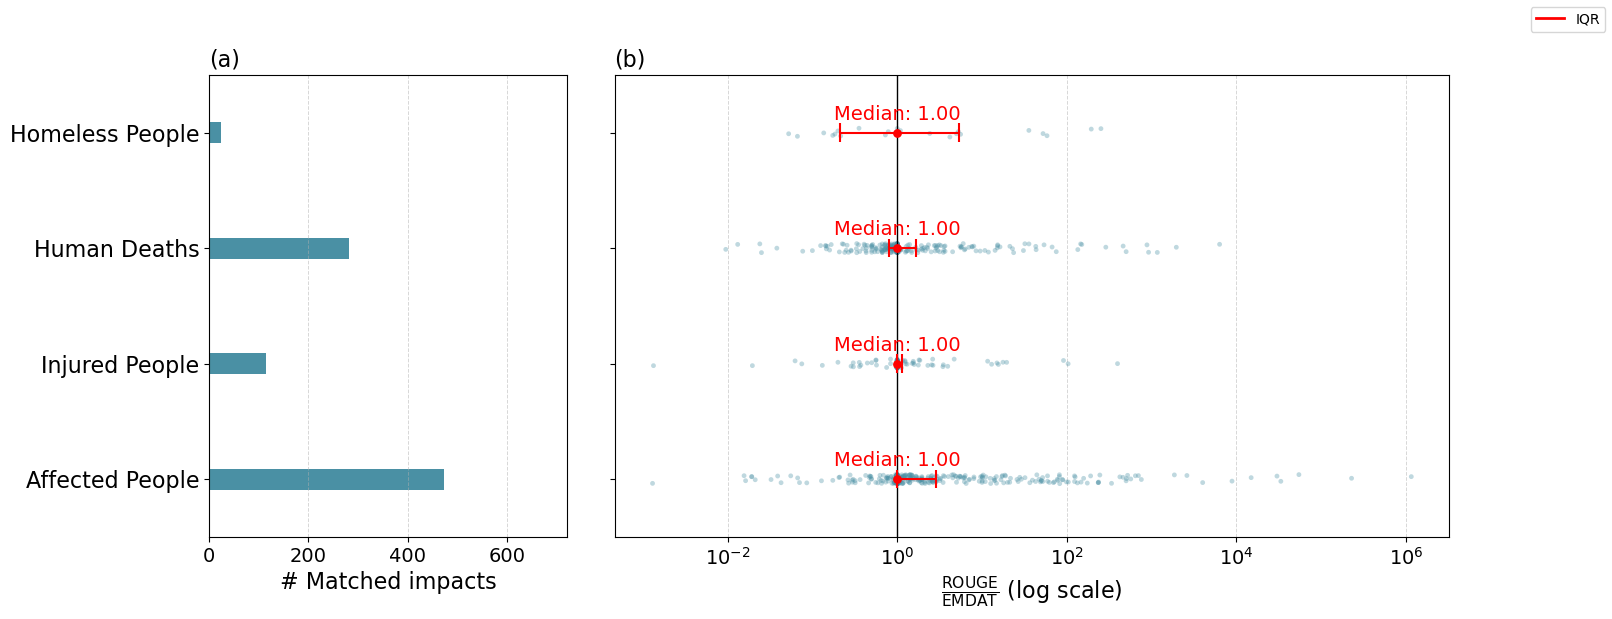

In [ ]:
# (a)-(b) Two-column aligned plot: report counts and jitter distributions (log scale)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Toggle to include IFRC Monty in both panels
INCLUDE_IFRC_MONTY = False

# Use ratio columns for log-scale jitter plot
# diff_metric = "ratio"
diff_metric = "ROUGE/EXTERNAL"

# Font sizes
tick_fs = 14
label_fs = 16
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
impact_counts = (
    impact_count_summary.set_index("impactSubtype")
    if "impactSubtype" in impact_count_summary.columns
    else impact_count_summary
)
impact_types = [
    it
    for it in impact_types
    if impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0) > 0
]
n_types = len(impact_types)
y = np.arange(n_types)

# Keep labels identical across both subplots for perfect row alignment
impact_labels = impact_types

# Pick IFRC key available in both dictionaries (prefer IFRCGO)
if "IFRCGO" in nb_matched and "IFRCGO" in df_matched_with_impact:
    ifrc_key = "IFRCGO"
else:
    ifrc_key = "IFRC MONTY"

# External sources to compare
ext_sources = ["EMDAT"]
if (
    INCLUDE_IFRC_MONTY
    and "IFRC MONTY" in nb_matched
    and "IFRC MONTY" in df_matched_with_impact
    and "IFRC MONTY" not in ext_sources
):
    ext_sources.append("IFRC MONTY")

# Build left-panel series (ROUGE + external sources)
left_series = ext_sources

# Dynamic lane spacing: keep all sources aligned across both panels
bar_h = 0.18
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary
counts_map = {
    "ROUGE": np.array(
        [
            impact_counts.get("ROUGE_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "EMDAT": np.array(
        [
            impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "IFRCGO": np.array(
        [
            impact_counts.get("IFRCGO_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "IFRC MONTY": np.array(
        [
            impact_counts.get("IFRC MONTY_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
}

# Use the maximum Tukey upper fence across the plotted count series for the left panel
left_count_arrays = [counts_map[s] for s in left_series if s in counts_map]
left_tukey_limits = []
for values in left_count_arrays:
    if len(values) == 0:
        continue
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1
    left_tukey_limits.append(q3 + 1.5 * iqr)

if left_tukey_limits:
    left_x_lim = float(np.nanmax(left_tukey_limits))
    if not np.isfinite(left_x_lim) or left_x_lim <= 0:
        left_x_lim = 1.0
else:
    left_x_lim = 1.0

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [0.3, 0.7], "wspace": 0.08},
    sharey=True,
)

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "IFRC MONTY": "#b08968",
}
bar_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "IFRC MONTY": "IFRC MONTY",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=bar_labels[s],
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=0, ha="right", fontsize=label_fs)
# ax_a.set_ylabel("Impact subtype")
ax_a.invert_yaxis()
ax_a.set_xlabel("# Matched impacts", fontsize=label_fs)
ax_a.set_title("(a)", fontsize=label_fs, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="x", labelsize=tick_fs)
ax_a.set_xlim(0, left_x_lim * 1.05)

# =====================
# (b) Horizontal jitter plot on log scale
# =====================
box_style = {
    "EMDAT": {"face": "#4a90a4", "edge": "#1f5f78"},
    "IFRCGO": {"face": "#7f7f7f", "edge": "#4d4d4d"},
    "IFRC MONTY": {"face": "#b08968", "edge": "#7f5539"},
}

rng = np.random.default_rng(42)
jitter_width = bar_h * 0.22

for s in ext_sources:
    for i, impact_type in enumerate(impact_types):
        vals = (
            df_matched_with_impact.get(s, pd.DataFrame())
            .loc[lambda d: d["impactSubtype"] == impact_type, diff_metric]
            .dropna()
            .values
        )

        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]

        if len(vals) == 0:
            continue

        y_center = y[i] + offset_map[s]
        y_jitter = y_center + rng.uniform(-jitter_width, jitter_width, size=len(vals))

        ax_b.scatter(
            vals,
            y_jitter,
            s=12,
            alpha=0.35,
            color=box_style[s]["face"],
            edgecolors="none",
            zorder=2,
        )

        med_val = float(np.median(vals))
        qt025 = np.percentile(vals, 25)
        qt075 = np.percentile(vals, 75)
        mean_val = float(np.mean(vals))

        ax_b.scatter(
            med_val,
            y_center,
            s=28,
            color="red",
            zorder=4,
        )
        ax_b.vlines(
            qt025,
            ymin=y_center - jitter_width * 2,
            ymax=y_center + jitter_width * 2,
            color="r",
            zorder=4,
        )
        ax_b.hlines(
            y_center,
            xmin=qt025,
            xmax=qt075,
            color="r",
            zorder=4,
        )
        ax_b.vlines(
            qt075,
            ymin=y_center - jitter_width * 2,
            ymax=y_center + jitter_width * 2,
            color="r",
            zorder=4,
        )
        ax_b.text(
            med_val,
            y_center + jitter_width * 2,
            f"Median: {med_val:.2f}",
            color="red",
            fontsize=14,
            ha="center",
            va="bottom",
        )

        # ax_b.scatter(
        #    mean_val,
        #    y_center,
        #    s=28,
        #    color="darkorange",
        #    zorder=4,
        # )
        # ax_b.text(
        #    mean_val,
        #    y_center - jitter_width * 7,
        #    f"Mean: {mean_val:.2f}",
        #    color="darkorange",
        #    fontsize=14,
        #    ha="center",
        #    va="bottom",
        # )

ax_b.axvline(1, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xscale("log")
ax_b.set_xlabel(
    r"$\frac{\mathrm{ROUGE}}{\mathrm{EMDAT}}$ (log scale)",
    fontsize=label_fs,
)
ax_b.set_title("(b)", fontsize=label_fs, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)
ax_b.set_ylim(-0.5, n_types - 0.5)

# Keep one shared y definition while hiding labels on the right panel
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=0, ha="right", fontsize=label_fs)
ax_b.tick_params(axis="y", labelleft=False)

# Single shared legend for both subplots
shared_handles = [
    Patch(
        facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=bar_labels[s]
    )
    for s in ext_sources
]
iqr_handle = Line2D([0], [0], color="red", linewidth=2, label="IQR")
#shared_handles.append(iqr_handle)
fig.legend(
    handles=[iqr_handle],
    #loc="lower center",
    #ncol=len(shared_handles),
    #frameon=False,
    #bbox_to_anchor=(0.5, -0.04),
    #fontsize=legend_fs,
    #title_fontsize=legend_fs,
)
# fig.legend(
#    handles=shared_handles,
#    loc="lower center",
#    ncol=len(shared_handles),
#    frameon=False,
#    bbox_to_anchor=(0.5, -0.04),
#    fontsize=legend_fs,
#    title_fontsize=legend_fs,
# )
plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save figure

fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_only_jitter.png",
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_only_jitter.svg",
            format="svg", transparent=True, bbox_inches='tight', dpi=300)

In [ ]:
df_matched_with_impact["IFRCGO"]

,impactValue_final,location,locationOsm,impactSubtype,impactValue,impactValuePrecision,impactUnit,valueAnnotation,valid_errors_impactValue,locationAnnotation,...,IFRCGO_glide,IFRCGO_updated_at,IFRCGO_impactSubtype,IFRCGO_impactValue,abs_diff,rel_diff,abs_rel_diff,EXTERNAL/ROUGE,ROUGE/EXTERNAL,match
0,7500000.0,,"['Honduras', 'Nicaragua', 'Sendero Guatemala']",Affected People,7500000.0,exact,people,['These two hurricanes affected more than 7.5 ...,0.0,['These two hurricanes affected more than 7.5 ...,...,TC-2020-000220-HND,2022-08-12T14:44:05.269022Z,Affected People,200000.0,7300000.0,36.500000,36.500000,0.026667,37.500000,False
1,249900.0,,['Afghanistan'],Affected People,249900.0,exact,people,"['Number of people affected: 249,900']",0.0,"['Number of people affected: 249,900']",...,FL-2022-000262-AFG,2024-06-03T18:15:18.094806Z,Affected People,249900.0,0.0,0.000000,0.000000,1.000000,1.000000,True
2,325205.0,Badakhshan; Badghis; Balkh; Farah; Faryab; Gho...,"['Afghanistan', 'Farah Province', 'Ghor Provin...",Affected People,325205.0,exact,people,"['People Affected: 325,205 people']",0.0,['The hardest-hit provinces included Badakhsha...,...,NaN,2024-03-04T18:35:28.334998Z,Affected People,5404.0,319801.0,59.178571,59.178571,0.016617,60.178571,False
3,280000.0,,['Afghanistan'],Affected People,280000.0,exact,people,"['These floods directly impacted over 280,000 ...",0.0,"['These floods directly impacted over 280,000 ...",...,2024-000049,2024-05-25T05:17:32.889099Z,Affected People,83000.0,197000.0,2.373494,2.373494,0.296429,3.373494,False
4,202291.0,,['Albania'],Affected People,202291.0,exact,people,"['Number of people affected: 202,291']",0.0,"['Number of people affected: 202,291']",...,EQ-2019-000157-ALB,2024-06-03T18:17:58.154955Z,Affected People,222000.0,19709.0,-0.088779,0.088779,1.097429,0.911221,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
813,66.0,,['Viet Nam'],Missing People,66.0,exact,people,"['357 dead or missing (291 fatalities, 66 miss...",0.0,"['357 dead or missing (291 fatalities, 66 miss...",...,NaN,2021-09-30T08:03:50.403105Z,Missing People,0.0,66.0,NaN,NaN,0.000000,NaN,False
814,22.0,,['Viet Nam'],Missing People,22.0,exact,people,"['As of 15 October 2024, Typhoon Yagi has resu...",0.0,"['As of 15 October 2024, Typhoon Yagi has resu...",...,NaN,2025-07-16T00:43:11.029197Z,Missing People,82.0,60.0,-0.731707,0.731707,3.727273,0.268293,False
815,88.0,uMkhanyakude; uThukela; uMzinyathi; UMgungundl...,"['South Africa', 'Umkhanyakude District Munici...",Missing People,88.0,exact,people,['Table 1: Cumulative summary of flood impacts...,0.0,['Table 1: Cumulative summary of flood impacts...,...,NaN,2022-04-13T04:45:15.196476Z,Missing People,3.0,85.0,28.333333,28.333333,0.034091,29.333333,False
816,12.0,Mpumalanga; Eastern Cape,"['Mpumalanga', 'Eastern Cape']",Missing People,12.0,exact,people,['Mpumalanga and Eastern Cape were identified ...,0.0,['Mpumalanga and Eastern Cape were identified ...,...,NaN,2024-06-03T18:13:56.937164Z,Missing People,0.0,12.0,NaN,NaN,0.000000,NaN,False


In [ ]:
df_matched_with_impact.keys()

dict_keys(['IFRCGO', 'ALL', 'EMDAT'])

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_34504\3964298087.py:274: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


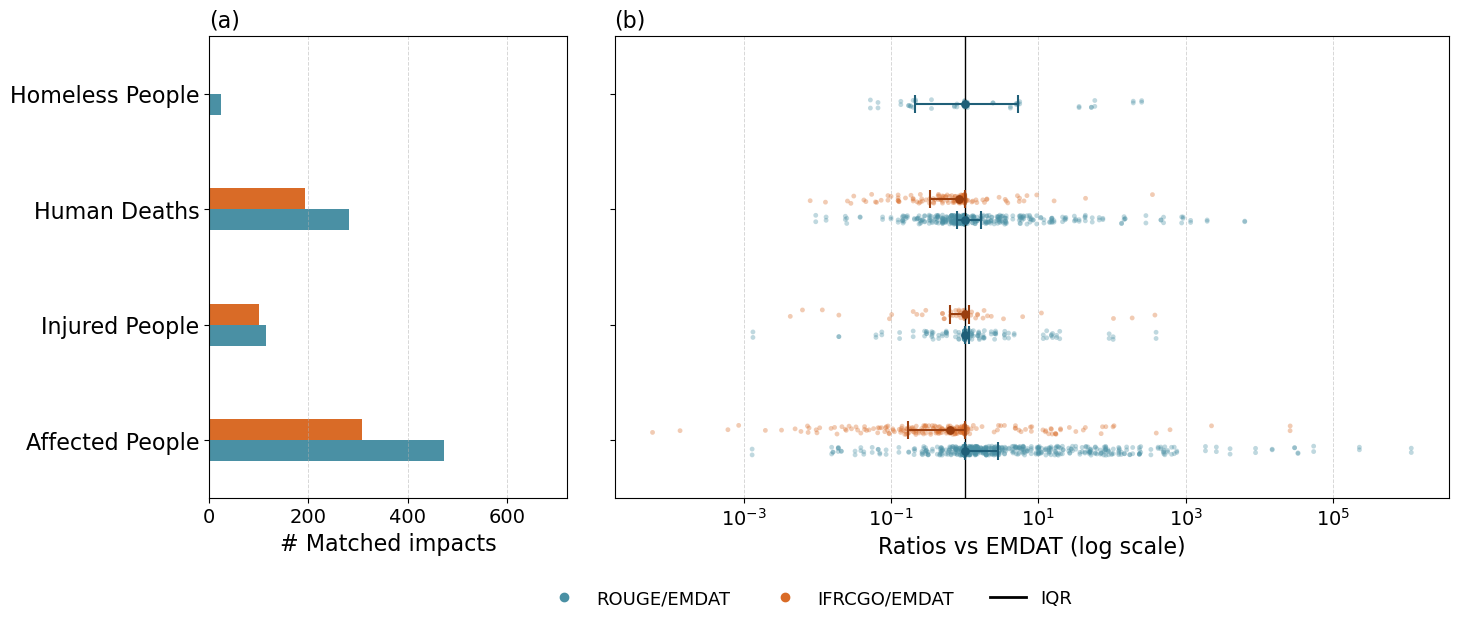

In [ ]:
# (a)-(b) Two-column aligned plot: report counts and jitter distributions (log scale)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

# Toggle to include IFRC Monty in both panels
INCLUDE_IFRC_MONTY = False

# EMDAT is the reference for all jitter ratios
reference = "EMDAT"

# Font sizes
tick_fs = 14
label_fs = 16
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
impact_counts = (
    impact_count_summary.set_index("impactSubtype")
    if "impactSubtype" in impact_count_summary.columns
    else impact_count_summary
)
impact_types = [
    it
    for it in impact_types
    if impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0) > 0
]
n_types = len(impact_types)
y = np.arange(n_types)

# Keep labels identical across both subplots for perfect row alignment
impact_labels = impact_types

# External sources to compare in panel (a)
left_series = ["EMDAT", "IFRCGO"]
if (
    INCLUDE_IFRC_MONTY
    and "IFRC MONTY" in impact_counts.columns
    and "IFRC MONTY" not in left_series
):
    left_series.append("IFRC MONTY")

# Two jitter series in panel (b), both with EMDAT as denominator
jitter_series = [
    {
        "name": "ROUGE/EMDAT",
        "df_key": "EMDAT",
        "ratio_col": "ROUGE/EMDAT",
        "face": "#4a90a4",
        "edge": "#1f5f78",
    },
    {
        "name": "IFRCGO/EMDAT",
        "df_key": "IFRCGO",
        "ratio_col": "IFRCGO/EMDAT",
        "face": "#d96b27",
        "edge": "#9a3e0e",
    },
]

# Dynamic lane spacing: keep all sources aligned across both panels
bar_h = 0.18
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Offsets dedicated to the two jitter ratios
jitter_offsets = np.linspace(
    -bar_h * (len(jitter_series) - 1) / 2,
    bar_h * (len(jitter_series) - 1) / 2,
    len(jitter_series),
)
jitter_offset_map = {cfg["name"]: jitter_offsets[i] for i, cfg in enumerate(jitter_series)}

# Counts for panel (a)
counts_map = {
    "ROUGE": np.array(
        [
            impact_counts.get("ROUGE_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "EMDAT": np.array(
        [
            impact_counts.get("EMDAT_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "IFRCGO": np.array(
        [
            impact_counts.get("IFRCGO_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
    "IFRC MONTY": np.array(
        [
            impact_counts.get("IFRC MONTY_count", pd.Series(dtype=float)).get(it, 0)
            for it in impact_types
        ],
        dtype=float,
    ),
}

# Use the maximum Tukey upper fence across the plotted count series for the left panel
left_count_arrays = [counts_map[s] for s in left_series if s in counts_map]
left_tukey_limits = []
for values in left_count_arrays:
    if len(values) == 0:
        continue
    q1 = np.nanpercentile(values, 25)
    q3 = np.nanpercentile(values, 75)
    iqr = q3 - q1
    left_tukey_limits.append(q3 + 1.5 * iqr)

if left_tukey_limits:
    left_x_lim = float(np.nanmax(left_tukey_limits))
    if not np.isfinite(left_x_lim) or left_x_lim <= 0:
        left_x_lim = 1.0
else:
    left_x_lim = 1.0

# Create side-by-side panels sharing y to guarantee alignment
fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(16, max(6, 0.7 * n_types + 3)),
    gridspec_kw={"width_ratios": [0.3, 0.7], "wspace": 0.08},
    sharey=True,
)

# =====================
# (a) Horizontal grouped bar plot
# =====================
bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#d96b27",
    "IFRC MONTY": "#b08968",
}
bar_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "IFRC MONTY": "IFRC MONTY",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=bar_labels[s],
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=0, ha="right", fontsize=label_fs)
ax_a.invert_yaxis()
ax_a.set_xlabel("# Matched impacts", fontsize=label_fs)
ax_a.set_title("(a)", fontsize=label_fs, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="x", labelsize=tick_fs)
ax_a.set_xlim(0, left_x_lim * 1.05)

# =====================
# (b) Horizontal jitter plot on log scale
# =====================
rng = np.random.default_rng(42)
jitter_width = bar_h * 0.22

for cfg in jitter_series:
    s_name = cfg["name"]
    df_key = cfg["df_key"]
    ratio_col = cfg["ratio_col"]

    df_src = df_matched_with_impact.get(df_key, pd.DataFrame())
    if ratio_col not in df_src.columns:
        continue

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_src.loc[lambda d: d["impactSubtype"] == impact_type, ratio_col]
            .dropna()
            .values
        )

        vals = vals[np.isfinite(vals)]
        vals = vals[vals > 0]

        if len(vals) == 0:
            continue

        y_center = y[i] + jitter_offset_map[s_name]
        y_jitter = y_center + rng.uniform(-jitter_width, jitter_width, size=len(vals))

        ax_b.scatter(
            vals,
            y_jitter,
            s=12,
            alpha=0.35,
            color=cfg["face"],
            edgecolors="none",
            zorder=2,
        )

        med_val = float(np.median(vals))
        qt025 = np.percentile(vals, 25)
        qt075 = np.percentile(vals, 75)

        ax_b.scatter(
            med_val,
            y_center,
            s=28,
            color=cfg["edge"],
            zorder=4,
        )
        ax_b.vlines(
            qt025,
            ymin=y_center - jitter_width * 2,
            ymax=y_center + jitter_width * 2,
            color=cfg["edge"],
            zorder=4,
        )
        ax_b.hlines(
            y_center,
            xmin=qt025,
            xmax=qt075,
            color=cfg["edge"],
            zorder=4,
        )
        ax_b.vlines(
            qt075,
            ymin=y_center - jitter_width * 2,
            ymax=y_center + jitter_width * 2,
            color=cfg["edge"],
            zorder=4,
        )

ax_b.axvline(1, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xscale("log")
ax_b.set_xlabel("Ratios vs EMDAT (log scale)", fontsize=label_fs)
ax_b.set_title("(b)", fontsize=label_fs, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)
ax_b.set_ylim(-0.5, n_types - 0.5)

# Keep one shared y definition while hiding labels on the right panel
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=0, ha="right", fontsize=label_fs)
ax_b.tick_params(axis="y", labelleft=False)

# Legends
ratio_handles = [
    Line2D([0], [0], marker="o", linestyle="", color=cfg["face"], label=cfg["name"])
    for cfg in jitter_series
]
iqr_handle = Line2D([0], [0], color="black", linewidth=2, label="IQR")
fig.legend(
    handles=ratio_handles + [iqr_handle],
    loc="lower center",
    ncol=3,
    frameon=False,
    bbox_to_anchor=(0.5, -0.1),
    fontsize=legend_fs,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])

# Save figure

# fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_reference_jitter.png",
#             transparent=True, bbox_inches='tight', dpi=300)
# fig.savefig(path_save_fig / f"comparaison_external_events_values_emdat_reference_jitter.svg",
#             format="svg", transparent=True, bbox_inches='tight', dpi=300)

C:\Users\lhasbini\AppData\Local\Temp\ipykernel_38512\2911563892.py:158: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.06, 1, 1])


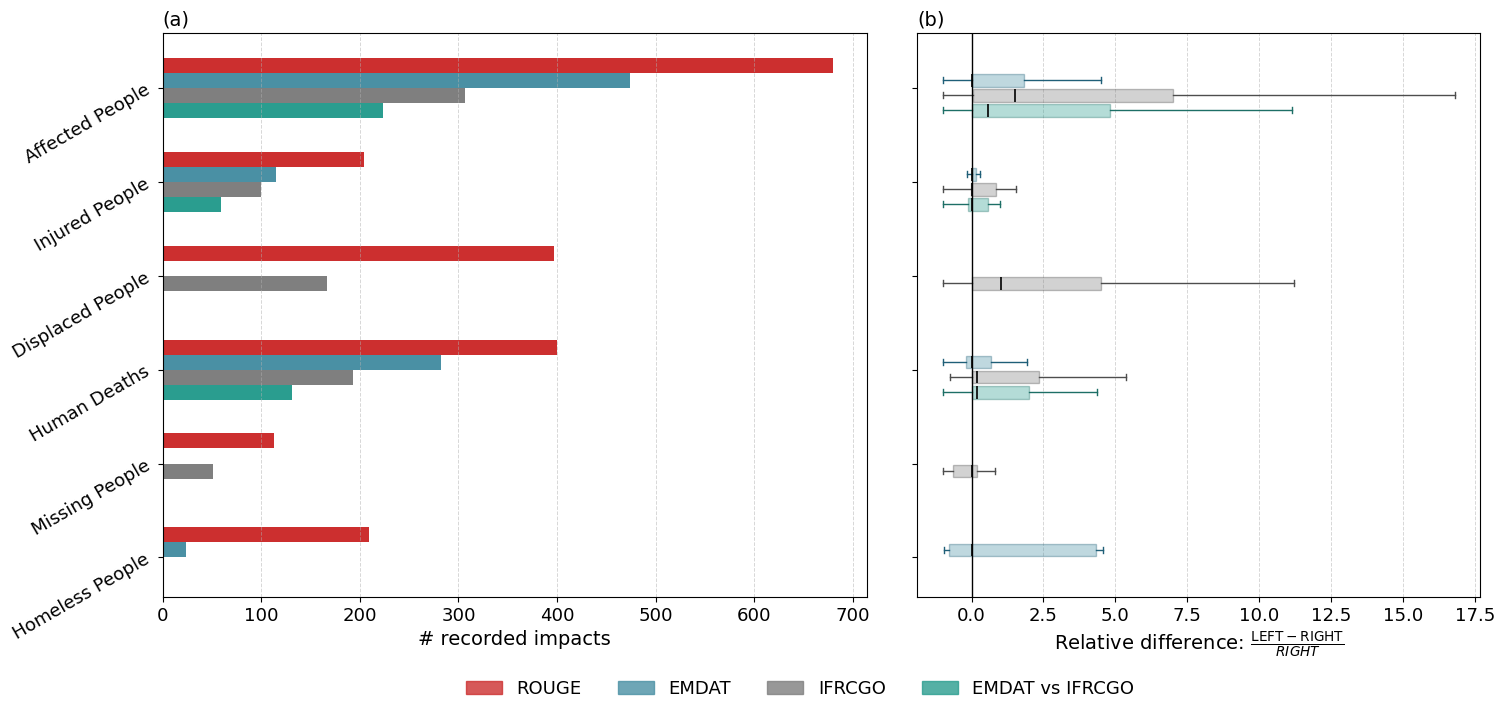

In [ ]:
# (a)-(b) Alternative comparison including EMDAT vs IFRCGO pairwise metrics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

INCLUDE_IFRC_MONTY = False
tick_fs = 13
legend_fs = 13

impact_types = list(mapping_impact_type.keys())
n_types = len(impact_types)
y = np.arange(n_types)
impact_labels = impact_types

# Pairwise count: number of recorded impacts with both EMDAT and IFRCGO values
pair_col = "EMDAT_vs_IFRCGO_rel_diff"
df_all_pair = df_matched_with_impact.get("ALL", pd.DataFrame()).copy()
if pair_col in df_all_pair.columns:
    pair_counts_series = (
        df_all_pair.loc[df_all_pair[pair_col].notna()]
        .groupby("impactSubtype")["appealCode"]
        .nunique()
    )
else:
    pair_counts_series = pd.Series(dtype=float)
pair_counts = np.array([pair_counts_series.get(it, 0) for it in impact_types], dtype=float)

# Sources to display in this version
left_series = ["ROUGE", "EMDAT", "IFRCGO", "EMDAT_vs_IFRCGO"]
bar_h = 0.16
offsets = np.linspace(
    -bar_h * (len(left_series) - 1) / 2,
    bar_h * (len(left_series) - 1) / 2,
    len(left_series),
)
offset_map = dict(zip(left_series, offsets))

# Counts for panel (a) - extracted from impact_count_summary (except pairwise)
counts_map = {
    "ROUGE": np.array(impact_count_summary['ROUGE_count'].values, dtype=float),
    "EMDAT": np.array(impact_count_summary['EMDAT_count'].values, dtype=float),
    "IFRCGO": np.array(impact_count_summary['IFRCGO_count'].values, dtype=float),
    "EMDAT_vs_IFRCGO": pair_counts,
}

fig, (ax_a, ax_b) = plt.subplots(
    1,
    2,
    figsize=(17, max(6, 0.72 * n_types + 3)),
    gridspec_kw={"width_ratios": [1.25, 1.0], "wspace": 0.08},
    sharey=True,
)

bar_colors = {
    "ROUGE": "#cc2f2f",
    "EMDAT": "#4a90a4",
    "IFRCGO": "#7f7f7f",
    "EMDAT_vs_IFRCGO": "#2a9d8f",
}

for s in left_series:
    ax_a.barh(
        y + offset_map[s],
        counts_map[s],
        height=bar_h,
        color=bar_colors[s],
        label=s.replace("_", " "),
    )

ax_a.set_yticks(y)
ax_a.set_yticklabels(impact_labels, rotation=30, ha="right")
ax_a.invert_yaxis()
ax_a.set_xlabel("# recorded impacts", fontsize=tick_fs + 1)
ax_a.set_title("(a)", fontsize=tick_fs + 1, loc="left")
ax_a.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_a.tick_params(axis="both", labelsize=tick_fs)

# Boxplots
box_h = bar_h * 0.85
box_specs = [
    {"key": "EMDAT", "df_key": "EMDAT", "col": "rel_diff", "face": "#4a90a4", "edge": "#1f5f78"},
    {"key": "IFRCGO", "df_key": "IFRCGO", "col": "rel_diff", "face": "#7f7f7f", "edge": "#4d4d4d"},
    {"key": "EMDAT_vs_IFRCGO", "df_key": "ALL", "col": "EMDAT_vs_IFRCGO_rel_diff", "face": "#2a9d8f", "edge": "#1d6f66"},
]

for spec in box_specs:
    box_vals = []
    box_pos = []
    df_src = df_matched_with_impact.get(spec["df_key"], pd.DataFrame())

    if spec["col"] not in df_src.columns:
        continue

    for i, impact_type in enumerate(impact_types):
        vals = (
            df_src.loc[df_src["impactSubtype"] == impact_type, spec["col"]]
            .dropna()
            .values
        )
        if len(vals) > 0:
            box_vals.append(vals)
            box_pos.append(y[i] + offset_map[spec["key"]])

    if box_vals:
        bp = ax_b.boxplot(
            box_vals,
            positions=box_pos,
            vert=False,
            widths=box_h,
            patch_artist=True,
            showfliers=False,
        )

        for box in bp["boxes"]:
            box.set_facecolor(spec["face"])
            box.set_alpha(0.35)
            box.set_edgecolor(spec["edge"])
        for median in bp["medians"]:
            median.set_color("black")
            median.set_linewidth(1.2)
        for whisker in bp["whiskers"]:
            whisker.set_color(spec["edge"])
        for cap in bp["caps"]:
            cap.set_color(spec["edge"])

ax_b.axvline(0, color="black", linewidth=1)
ax_b.grid(axis="x", linestyle="--", linewidth=0.7, alpha=0.5)
ax_b.set_xlabel(
    "Relative difference: " + r"$\frac{\mathrm{LEFT-RIGHT}}{RIGHT}$",
    fontsize=tick_fs + 1,
 )
ax_b.set_title("(b)", fontsize=tick_fs + 1, loc="left")
ax_b.tick_params(axis="x", labelsize=tick_fs)
ax_b.set_yticks(y)
ax_b.set_yticklabels(impact_labels, rotation=20, ha="right")
ax_b.tick_params(axis="y", labelleft=False)

legend_labels = {
    "ROUGE": "ROUGE",
    "EMDAT": "EMDAT",
    "IFRCGO": "IFRCGO",
    "EMDAT_vs_IFRCGO": "EMDAT vs IFRCGO",
}
shared_handles = [
    Patch(facecolor=bar_colors[s], edgecolor=bar_colors[s], alpha=0.8, label=legend_labels[s])
    for s in left_series
]
fig.legend(
    handles=shared_handles,
    loc="lower center",
    ncol=len(shared_handles),
    frameon=False,
    bbox_to_anchor=(0.5, -0.05),
    fontsize=legend_fs,
 )

plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

## Difference between IFRCGo and EMDAT 

In [ ]:
# Focus first over the events that we also extract with ROUGE


## Differences in days IFRC Go

In [ ]:
df = df_matched_with_impact["ifrc_go"]

# keep only keys that are actual columns
valid_cols = [c for c in mapping_impact_type.keys() if c in df.columns]

df_result = (
    df[
          ["appealCode", "impactSubtype", "impactValue_final", "abs_diff", "rel_diff", "reportLink", "reportDate", "appeals_start_date", "appeals_end_date", "valueAnnotation"] + valid_cols
      ]
)

In [ ]:
# Distribution of the date difference between appeals_end_date and reportDate for all the unique appealCodes in df_result
# Parse both columns in UTC (handles mixed tz-aware/naive inputs), then drop tz for safe subtraction
df_result = df_result.copy()

df_result["reportDate"] = (
    pd.to_datetime(df_result["reportDate"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_result["appeals_end_date"] = (
    pd.to_datetime(df_result["appeals_end_date"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)
df_result["appeals_start_date"] = (
    pd.to_datetime(df_result["appeals_start_date"], errors="coerce", utc=True)
    .dt.tz_convert(None)
)

df_result["date_diff_start"] = (df_result["reportDate"] - df_result["appeals_start_date"]).dt.days
df_result["date_diff_end"] = (df_result["reportDate"] - df_result["appeals_end_date"]).dt.days

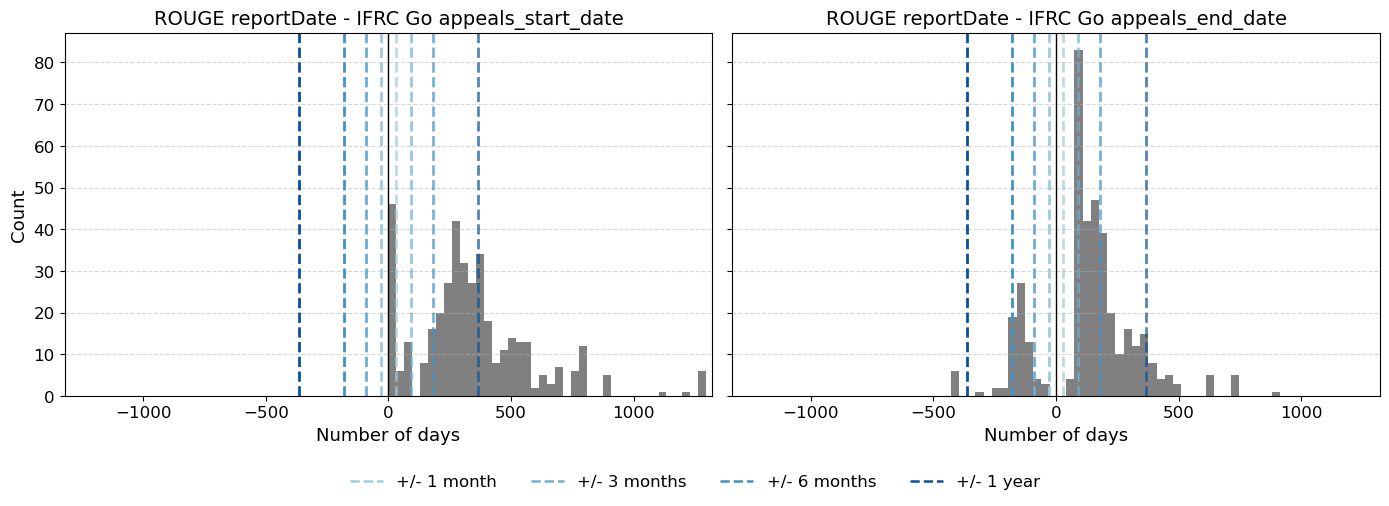

In [ ]:
# Histograms of report date differences vs appeals start/end dates
from matplotlib.lines import Line2D

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

thresholds = [30, 90, 30 * 6, 365]
threshold_labels = {30: "1 month", 90: "3 months", 180: "6 months", 365: "1 year"}
line_colors = ["#9ecae1", "#6baed6", "#4292c6", "#08519c"]

# Font sizes
title_fs = 14
label_fs = 13
tick_fs = 12
legend_fs = 12

hist_specs = [
    ("date_diff_start", "ROUGE reportDate - IFRC Go appeals_start_date"),
    ("date_diff_end", "ROUGE reportDate - IFRC Go appeals_end_date"),
]

# Use the same symmetric x-range for both plots
all_vals = pd.concat([df_result["date_diff_start"], df_result["date_diff_end"]], ignore_index=True).dropna()
if len(all_vals) > 0:
    max_abs = np.nanmax(np.abs(all_vals.values))
    x_lim = max(365, int(np.ceil(max_abs / 30.0) * 30))
else:
    x_lim = 365

for ax, (col, title) in zip(axes, hist_specs):
    vals = df_result[col].dropna()
    ax.hist(vals, bins=40, color="grey")

    # Add symmetric reference lines and labels directly above each line
    for d, c in zip(thresholds, line_colors):
        ax.axvline(d, color=c, linewidth=2, alpha=0.7, linestyle="--")
        ax.axvline(-d, color=c, linewidth=2, linestyle="--")

    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(title, fontsize=title_fs)
    ax.set_xlabel("Number of days", fontsize=label_fs)
    ax.set_xlim(-x_lim, x_lim)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    ax.tick_params(axis="both", labelsize=tick_fs)

axes[0].set_ylabel("Count", fontsize=label_fs)

# One shared legend for both subplots
legend_handles = [
    Line2D([0], [0], color=c, linestyle="--", linewidth=1.8, label=f"+/- {threshold_labels[d]}")
    for d, c in zip(thresholds, line_colors)
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.02),
    fontsize=legend_fs,
 )

plt.tight_layout(rect=[0, 0.07, 1, 1])
#Save figure
fig.savefig(path_save_fig / f"comparaison_ifrc_go_report_dates.png",
            transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(path_save_fig / f"comparaison_ifrc_go_report_dates.svg",
            format="svg", transparent=True, bbox_inches='tight', dpi=300)
plt.show()